In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jupyterlab.commands import enable_extension
from packaging.tags import platform_tags
from sklearn.metrics import roc_auc_score
from utils.visualization import *
from load_data import *
from morphomnist import morpho, perturb
import pickle
from glob import glob
import seaborn as sns

from utils.visualization import moving_out_of_distribution

In [2]:
legened_map = {
    'mc_dropout': 'MC Dropout',
    'ensemble': 'Deep Ensemble',
    'swag': 'SWAG',
    'laplace_approximation': 'Laplace Approximation',
    'ddu': 'DDU',
    'TTA': 'Test-Time Augmentation',
    'het_xl': 'HET-XL',
    'entropy': 'Entropy',
}
methods = {
    'epistemic_uncertainty': ["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "het_xl"],
    'aleatoric_uncertainty':["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "TTA", "het_xl"],
    'total_uncertainty': ["mc_dropout", "ensemble", "swag", "laplace_approximation", "ddu", "TTA", "het_xl", "entropy"]
}

print(legened_map.values())
colors = sns.color_palette("tab10", len(legened_map.values()))
palette_dict = dict(zip(legened_map.values(), colors))
palette_dict

dict_values(['MC Dropout', 'Deep Ensemble', 'SWAG', 'Laplace Approximation', 'DDU', 'Test-Time Augmentation', 'HET-XL', 'Entropy'])


{'MC Dropout': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'Deep Ensemble': (1.0, 0.4980392156862745, 0.054901960784313725),
 'SWAG': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Laplace Approximation': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392),
 'DDU': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Test-Time Augmentation': (0.5490196078431373,
  0.33725490196078434,
  0.29411764705882354),
 'HET-XL': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'Entropy': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)}

# mnist

##

In [2]:
val_ds = MorphoMNISTDataset('/home/msafa/PhD/morpho/Morpho-MNIST/data/plain/t10k-images-idx3-ubyte.gz', '/home/msafa/PhD/morpho/Morpho-MNIST/data/plain/t10k-labels-idx1-ubyte.gz')

In [3]:
for j, (batch, _) in enumerate(val_ds):
    plain_img = batch
    if j > 5:
        break
plt.imshow(plain_img.permute(1,2,0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.show()

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 3

In [ ]:
perturbations = [
    [perturb.Thinning(amount=0.1), perturb.Thinning(amount=.3), perturb.Thinning(amount=.5), perturb.Thinning(amount=.7), perturb.Thinning(amount=.9)],
    [perturb.Swelling(strength=2), perturb.Swelling(strength=3), perturb.Swelling(strength=5)],
    [perturb.Fracture(num_frac=1), perturb.Fracture(num_frac=3), perturb.Fracture(num_frac=5), perturb.Fracture(num_frac=10)],
    [perturb.Thickening(amount=0.5), perturb.Thickening(amount=1), perturb.Thickening(amount=2), perturb.Thickening(amount=3)],
]

In [ ]:
for k, per in enumerate(perturbations):
    fig, axs = plt.subplots(1, len(per)+1)
    axs[0].imshow(plain_img.permute(1,2,0).cpu().numpy(), cmap='gray')
    axs[0].set_axisbelow(True)
    axs[0].set_title('Original image')
    axs[0].axis('off')
    for i, p  in enumerate(per):
        try:
            name = p.amount
        except:
            try:
                name = p.num_frac
            except:
                name = p.strength
        ds = MorphoMNISTDataset('/home/msafa/PhD/morpho/Morpho-MNIST/data/plain/t10k-images-idx3-ubyte.gz', '/home/msafa/PhD/morpho/Morpho-MNIST/data/plain/t10k-labels-idx1-ubyte.gz', perturbation=p)
        for j, (batch, _) in enumerate(ds):
            img = batch
            if j > 5:
                break
        print(p, img.sum())
        axs[i+1].imshow(img.permute(1,2,0), cmap='gray')
        axs[i+1].set_title(name)
        axs[i+1].axis('off')
    plt.savefig('/home/msafa/PhD/benchmark/paper_plots/mnist_{per}.pdf'.format(per=k))
    plt.show()

In [ ]:
# per = [perturb.Thinning(amount=.1), perturb.Thinning(amount=.3), perturb.Thinning(amount=.7), perturb.Thinning(amount=.9)]
per = [perturb.Fracture(num_frac=1), perturb.Fracture(num_frac=3), perturb.Fracture(num_frac=5), perturb.Fracture(num_frac=10)]
fig, axs = plt.subplots(1, len(per))
for i, p  in enumerate(per):
    try:
        name = p.amount
    except:
        try:
            name = p.num_frac
        except:
            name = p.strength
    ds = MorphoMNISTDataset(f'/home/msafa/PhD/morpho/Morpho-MNIST/data/fracture/t10k-images-idx3-ubyte-{name}.gz', '/home/msafa/PhD/morpho/Morpho-MNIST/data/plain/t10k-labels-idx1-ubyte.gz')
    for j, (batch, _) in enumerate(ds):
        img = batch
        if j > 3:
            break
    print(p, img.sum())
    axs[i].imshow(img.permute(1,2,0), cmap='gray')
    axs[i].set_title(name)
    axs[i].axis('off')
plt.show()

In [2]:
ds = MorphoMNISTDataset(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data','plain', 'train-images-idx3-ubyte.gz'), os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data','plain', 'train-labels-idx1-ubyte.gz'))

In [3]:
dl  = DataLoader(ds)

In [6]:
for batch in dl:
    print(batch[0].min())
    break

tensor(0.)


In [14]:
plain_images = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'plain', 'train-images-idx3-ubyte.gz'))
blur_low_sever_images = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'train-images-blur-ks(5, 5)-s[1.0, 1.0].gz'))
blur_mid_sever_images = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'train-images-blur-ks(11, 11)-s[2.0, 2.0].gz'))
blur_high_sever_images = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'train-images-blur-ks(17, 17)-s[3.0, 3.0].gz'))

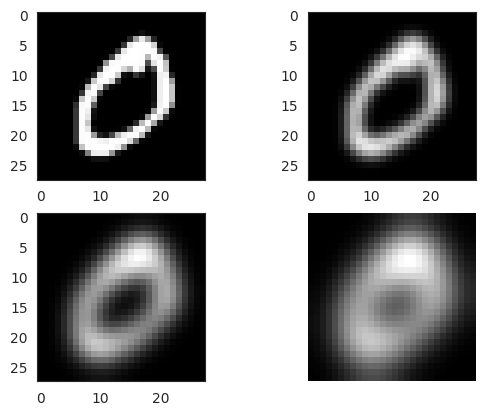

In [17]:
fig, ax = plt.subplots(2,2)
ax[0,0].imshow(plain_images[1], cmap='gray')
ax[0,1].imshow(blur_low_sever_images[1], cmap='gray')
ax[1,0].imshow(blur_mid_sever_images[1], cmap='gray')
ax[1,1].imshow(blur_high_sever_images[1], cmap='gray')
plt.axis('off')
plt.show()

In [18]:
labels = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'plain', 'train-labels-idx1-ubyte.gz'))

In [20]:
n = len(labels)
n_portion = n//4

In [ ]:

train_images= np.concatenate([plain_images[0:n_portion], blur_low_sever_images[n_portion:2*n_portion],blur_mid_sever_images[2*n_portion:3*n_portion],blur_high_sever_images[3*n_portion:4*n_portion]])


In [26]:
len(labels)

60000

(array([5923., 6742., 5958., 6131., 5842., 5421., 5918., 6265., 5851.,
        5949.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

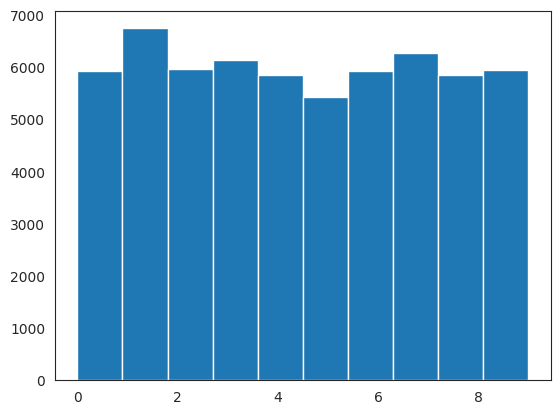

In [25]:
plt.hist(labels)

In [29]:
print(len(labels[3*n_portion:4*n_portion-200]))

15000


(array([1495., 1614., 1515., 1563., 1467., 1365., 1454., 1601., 1503.,
        1423.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

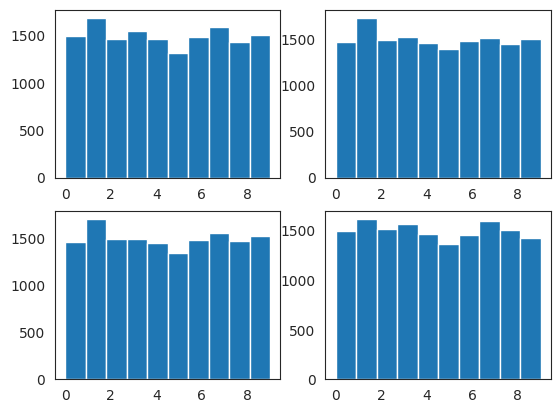

In [31]:
fig, ax = plt.subplots(2,2)
ax[0,0].hist(labels[0:n_portion])
ax[0,1].hist(labels[n_portion:2*n_portion])
ax[1,0].hist(labels[2*n_portion:3*n_portion])
ax[1,1].hist(labels[3*n_portion:4*n_portion])

In [38]:
l1 = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'plain', 't10k-labels-idx1-ubyte.gz'))
l2 = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'val-labels-blur-ks(17, 17)-s[3.0, 3.0].gz'))
l3 = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'val-labels-blur-ks(11, 11)-s[2.0, 2.0].gz'))
l4 = pars_gzip_file(os.path.join('/home/msafa/PhD/morpho/Morpho-MNIST/data', 'blured', 'val-labels-blur-ks(5, 5)-s[1.0, 1.0].gz'))

In [40]:
(l1 == l4).all()

True

## Epistemic

### moving out of dist


In [25]:
train_dl, val_dl, test_dl = load_data('/home/msafa/PhD/morpho/Morpho-MNIST/data')

In [26]:
root = '/home/msafa/PhD/benchmark/experiments/morpho_mnist_result'

In [ ]:
dist_type = list(test_dl.keys())[1]
fig, ax = plt.subplots(2,4, figsize=(25,10))
for i, m in enumerate(methods):
    rows = []
    for distortion in test_dl[dist_type].keys():
        data = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}.pkl'), 'rb'))
        for u_type in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
            rows.append({
                'uncertainty': u_type,
                'Uncertainty Score': data[u_type].numpy(),
                'distortion': distortion,
            })
    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="distortion", y="Uncertainty Score", data=res, ax=ax[i//4, i%4])
    ax[i//4, i%4].tick_params(axis='x', rotation=60)
    ax[i//4, i%4].set_title(m)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'moving_out_of_distribution_{dist_type}.pdf'))
plt.show()

In [ ]:
for u_type in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    for method in methods:
        all_uncertainty={}
        for dist_type in test_dl.keys():
            all_uncertainty[dist_type] = {}
            for distortion in test_dl[dist_type].keys():
                data = pickle.load(open(os.path.join(root, method, 'result', f'testset_uncertainty_{dist_type}_{distortion}.pkl'), 'rb'))
                all_uncertainty[dist_type][distortion] = data

        plot = moving_out_of_distribution(all_uncertainty, uncertainty_type=u_type)
        plot.savefig(os.path.join(root, method, 'plots', f'{u_type}_moving_out_of_distribution.pdf'))
        plot.close()

total_uncertainty
       Distortion Level Uncertainty Score      method
0             thining 1          0.003385  MC Dropout
1             thining 1          0.003747  MC Dropout
2             thining 1          0.000363  MC Dropout
3             thining 1          0.000726  MC Dropout
4             thining 1          0.062525  MC Dropout
...                 ...               ...         ...
399995        thining 9          0.910099     Entropy
399996        thining 9           0.00336     Entropy
399997        thining 9           0.00012     Entropy
399998        thining 9          0.363171     Entropy
399999        thining 9          0.000005     Entropy

[400000 rows x 3 columns]
       Distortion Level Uncertainty Score      method
0            fracture 1          0.002861  MC Dropout
1            fracture 1          0.053984  MC Dropout
2            fracture 1           0.00694  MC Dropout
3            fracture 1           0.19469  MC Dropout
4            fracture 1          0.07

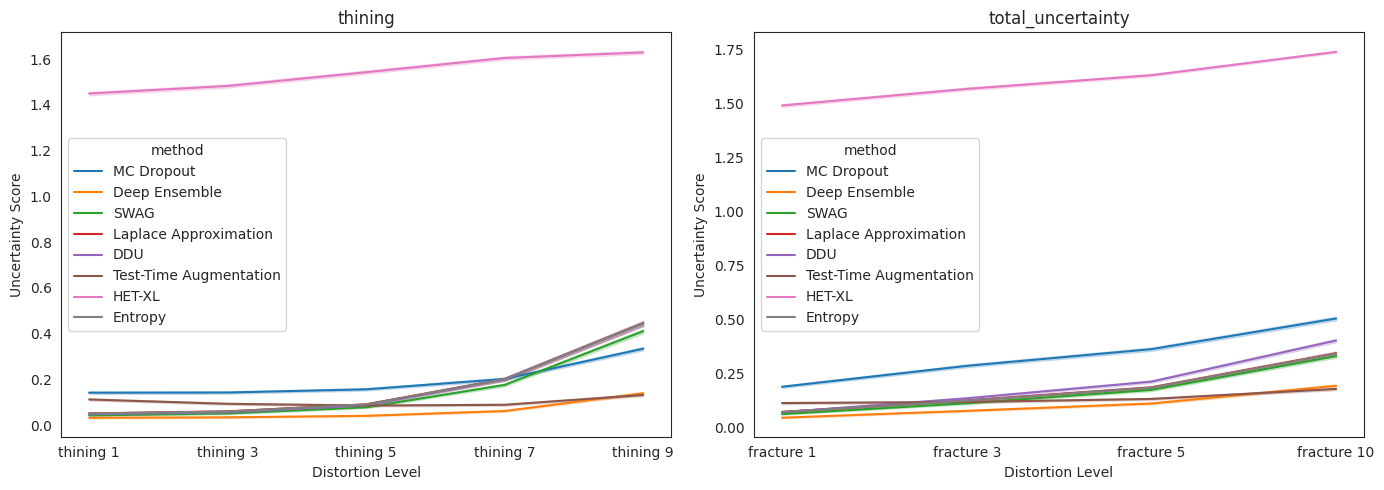

aleatoric_uncertainty
       Distortion Level Uncertainty Score      method
0             thining 1          0.001673  MC Dropout
1             thining 1          0.002175  MC Dropout
2             thining 1          0.000237  MC Dropout
3             thining 1          0.000453  MC Dropout
4             thining 1          0.014594  MC Dropout
...                 ...               ...         ...
349995        thining 9          0.913836      HET-XL
349996        thining 9          0.753228      HET-XL
349997        thining 9          0.868873      HET-XL
349998        thining 9          0.895151      HET-XL
349999        thining 9          0.346364      HET-XL

[350000 rows x 3 columns]
       Distortion Level Uncertainty Score      method
0            fracture 1          0.001625  MC Dropout
1            fracture 1          0.003476  MC Dropout
2            fracture 1          0.004246  MC Dropout
3            fracture 1            0.0081  MC Dropout
4            fracture 1          

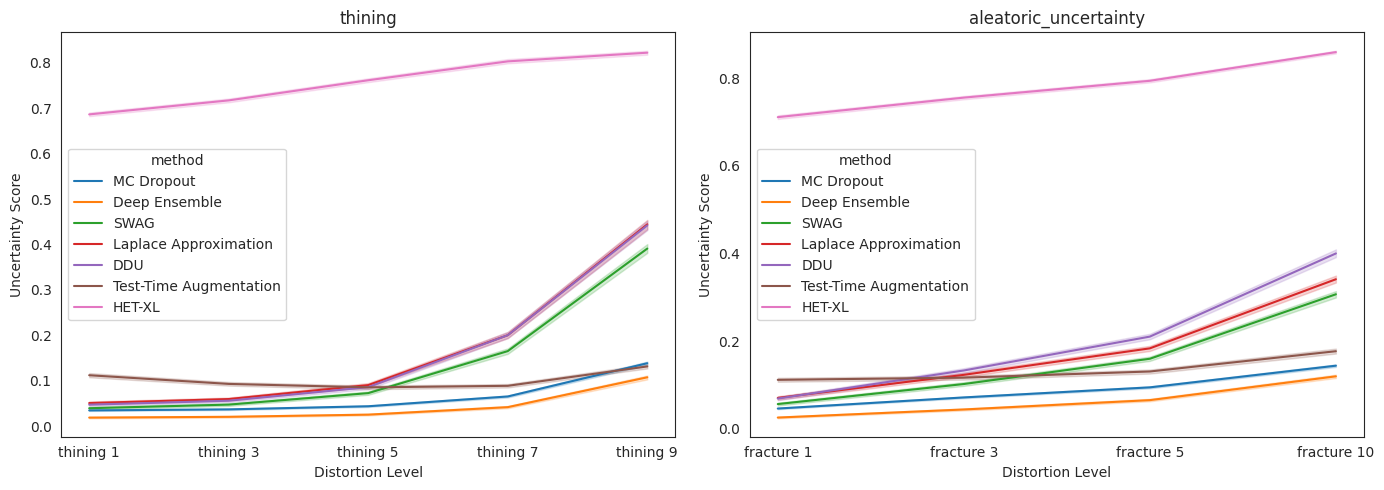

epistemic_uncertainty
       Distortion Level Uncertainty Score      method
0             thining 1          0.001712  MC Dropout
1             thining 1          0.001571  MC Dropout
2             thining 1          0.000126  MC Dropout
3             thining 1          0.000272  MC Dropout
4             thining 1          0.047931  MC Dropout
...                 ...               ...         ...
299995        thining 9          0.852927      HET-XL
299996        thining 9          1.018247      HET-XL
299997        thining 9          0.659004      HET-XL
299998        thining 9          0.815473      HET-XL
299999        thining 9          0.642195      HET-XL

[300000 rows x 3 columns]
       Distortion Level Uncertainty Score      method
0            fracture 1          0.001236  MC Dropout
1            fracture 1          0.050509  MC Dropout
2            fracture 1          0.002694  MC Dropout
3            fracture 1           0.18659  MC Dropout
4            fracture 1          

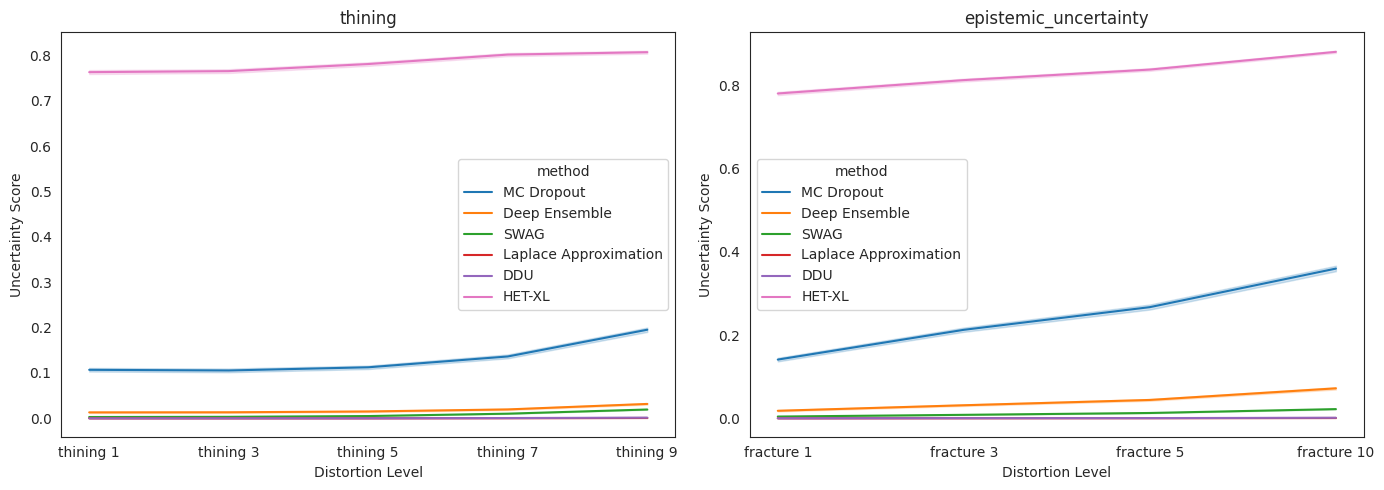

In [27]:
for k in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    print(k)
    all_uncertainty={}
    for dist_type in test_dl.keys():
        all_uncertainty[dist_type] = {}
        for method in methods[k]:
            all_uncertainty[dist_type][method] = {}
            for distortion in test_dl[dist_type].keys():
                data = pickle.load(open(os.path.join(root, method, 'result', f'testset_uncertainty_{dist_type}_{distortion}.pkl'), 'rb'))
                all_uncertainty[dist_type][method][distortion] = data

    plot = moving_out_of_distribution_compare(all_uncertainty, legend_map=legened_map, uncertainty_type=k, palette=palette_dict)
    plot.title(k)
    plot.savefig(os.path.join(root, 'common', 'plots', f'{k}_moving_out_of_distribution.pdf'))
    plt.show()
    plot.close()

### trend

In [43]:
root = ('/home/msafa/PhD/benchmark/experiments/mnist_epistemic_result')

In [44]:
train_dl, val_dl, test_dl = load_data_different_training_size('/home/msafa/PhD/morpho/Morpho-MNIST/data')

/tmp/ipykernel_11251/266579465.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4], palette=sns.color_palette('tab10'))
/tmp/ipykernel_11251/266579465.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4], palette=sns.color_palette('tab10'))
/tmp/ipykernel_11251/266579465.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4], palette=sns.color_palette('tab10'))
/tmp/ipykernel_11251/266579465.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4], palette=sns.color_palette('tab10'))
/tmp/ipykernel_11251/266579465.py:13: UserWarning: Ignor

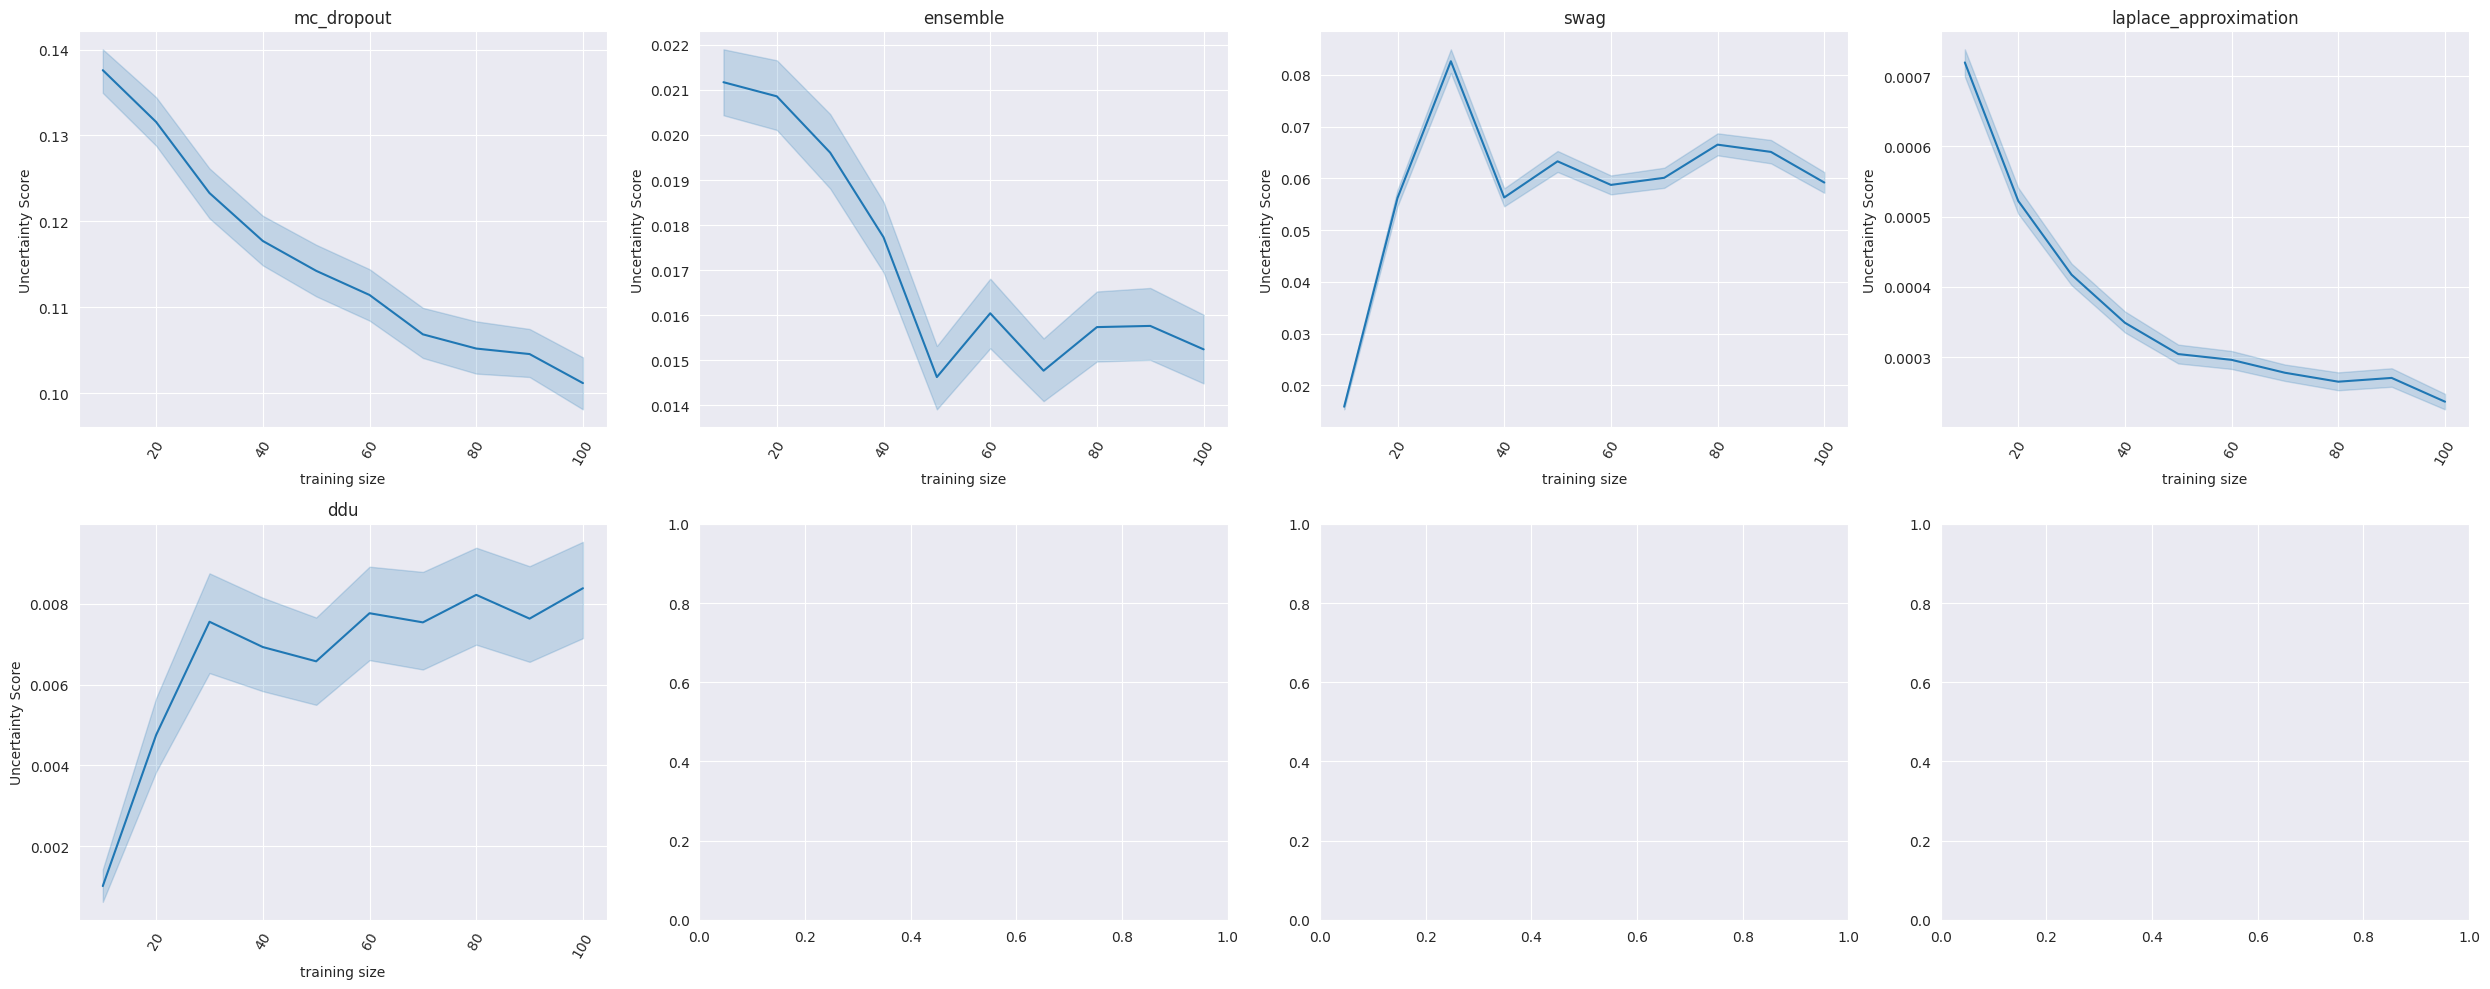

In [5]:
fig, ax = plt.subplots(2,4, figsize=(25,10))
for i, m in enumerate(methods['epistemic_uncertainty']):
    rows = []
    for distortion in train_dl.keys():
        data = pickle.load(open(os.path.join(root, m, 'result', f'validset_uncertainty_{distortion}.pkl'), 'rb'))
        for u_type in ['epistemic_uncertainty']:
            rows.append({
                'uncertainty': u_type,
                'Uncertainty Score': data[u_type].numpy(),
                'training size': distortion,
            })
    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4], palette=sns.color_palette('tab10'))
    ax[i//4, i%4].tick_params(axis='x', rotation=60)
    ax[i//4, i%4].set_title(m)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'epistemic_trend.pdf'))
plt.show()

/tmp/ipykernel_45582/3261979100.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([f'{x.get_text()}%' for x in ax[i].get_xticklabels()])
/tmp/ipykernel_45582/3261979100.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([f'{x.get_text()}%' for x in ax[i].get_xticklabels()])
/tmp/ipykernel_45582/3261979100.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels([f'{x.get_text()}%' for x in ax[i].get_xticklabels()])


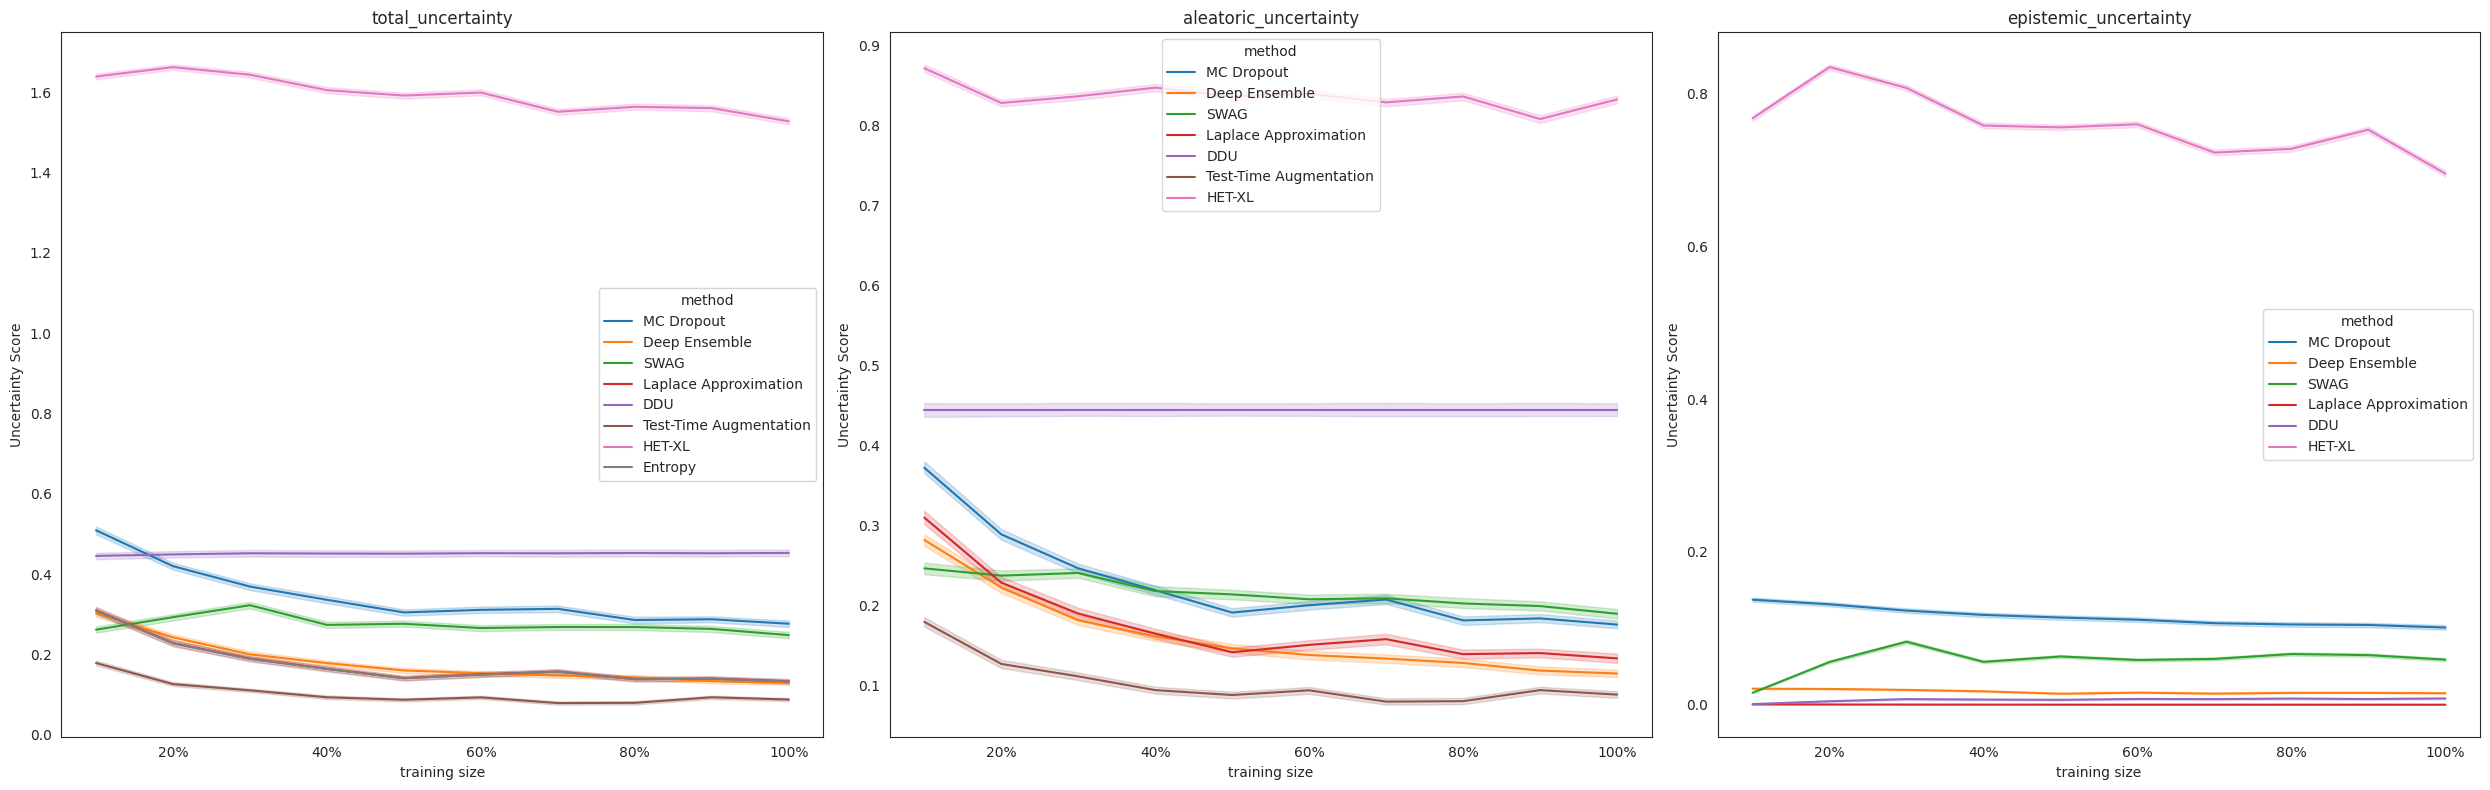

In [45]:
fig, ax = plt.subplots(1,3, figsize=(25,8))
sns.set_style('white')
for i, k in enumerate(['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']):
    rows = []
    for m in methods[k]:
        for distortion in train_dl.keys():
            data = pickle.load(open(os.path.join(root, m, 'result', f'validset_uncertainty_{distortion}.pkl'), 'rb'))
            rows.append({
                'uncertainty': k,
                'Uncertainty Score': data[k].numpy(),
                'training size': distortion,
                'method': legened_map[m]
            })
    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="training size", y="Uncertainty Score", data=res, hue='method', ax=ax[i], palette=palette_dict)
    # ax[i].tick_params(axis='x', rotation=60)
    ax[i].set_xticklabels([f'{x.get_text()}%' for x in ax[i].get_xticklabels()])
    ax[i].set_title(k)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'epistemic_trend.pdf'))
plt.show()

### AUROC

In [28]:
root = '/home/msafa/PhD/benchmark/experiments/morpho_mnist_result'

In [29]:
train_dl, val_dl, test_dl = load_data('/home/msafa/PhD/morpho/Morpho-MNIST/data')

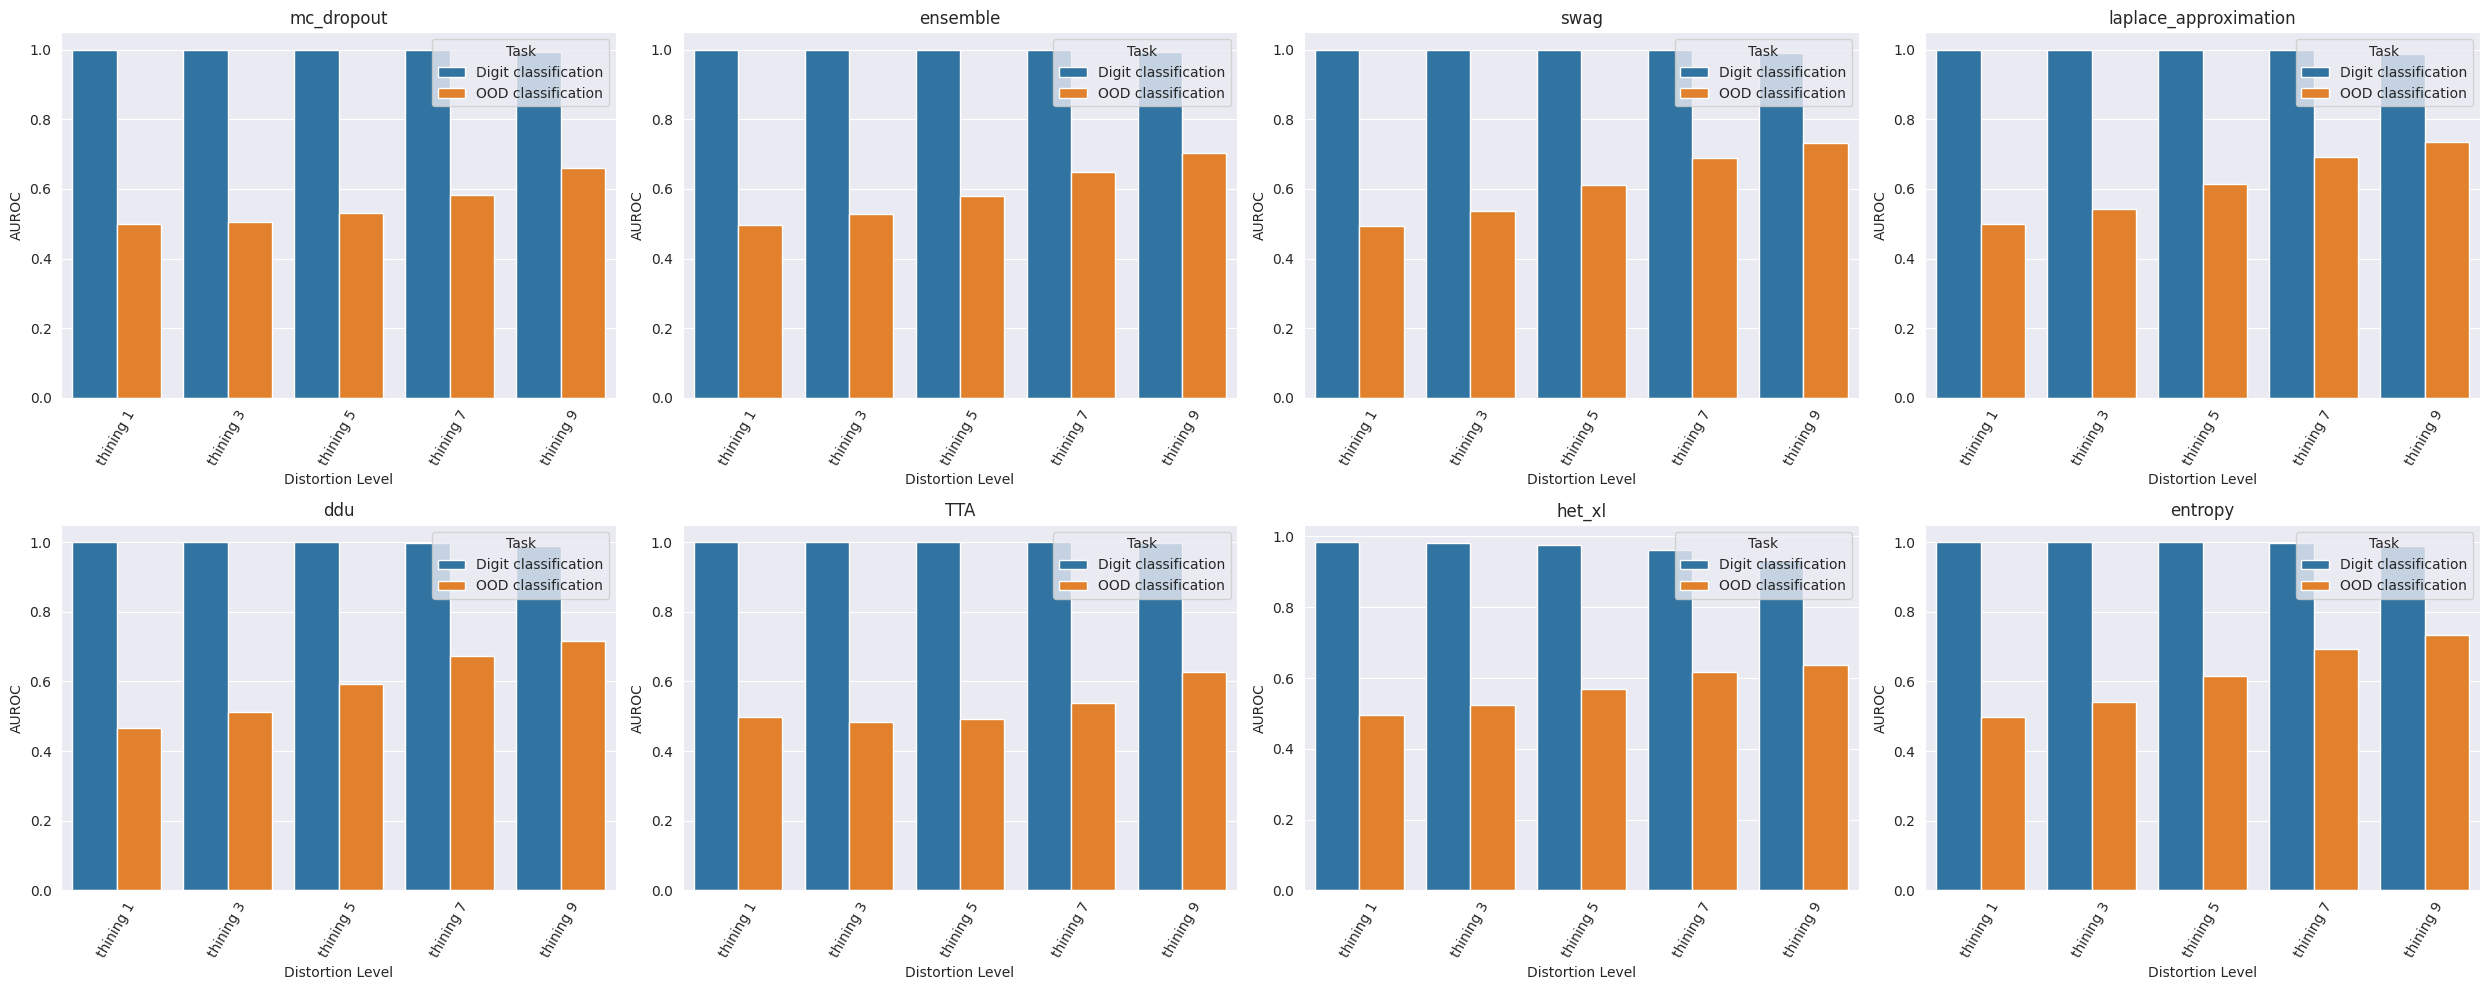

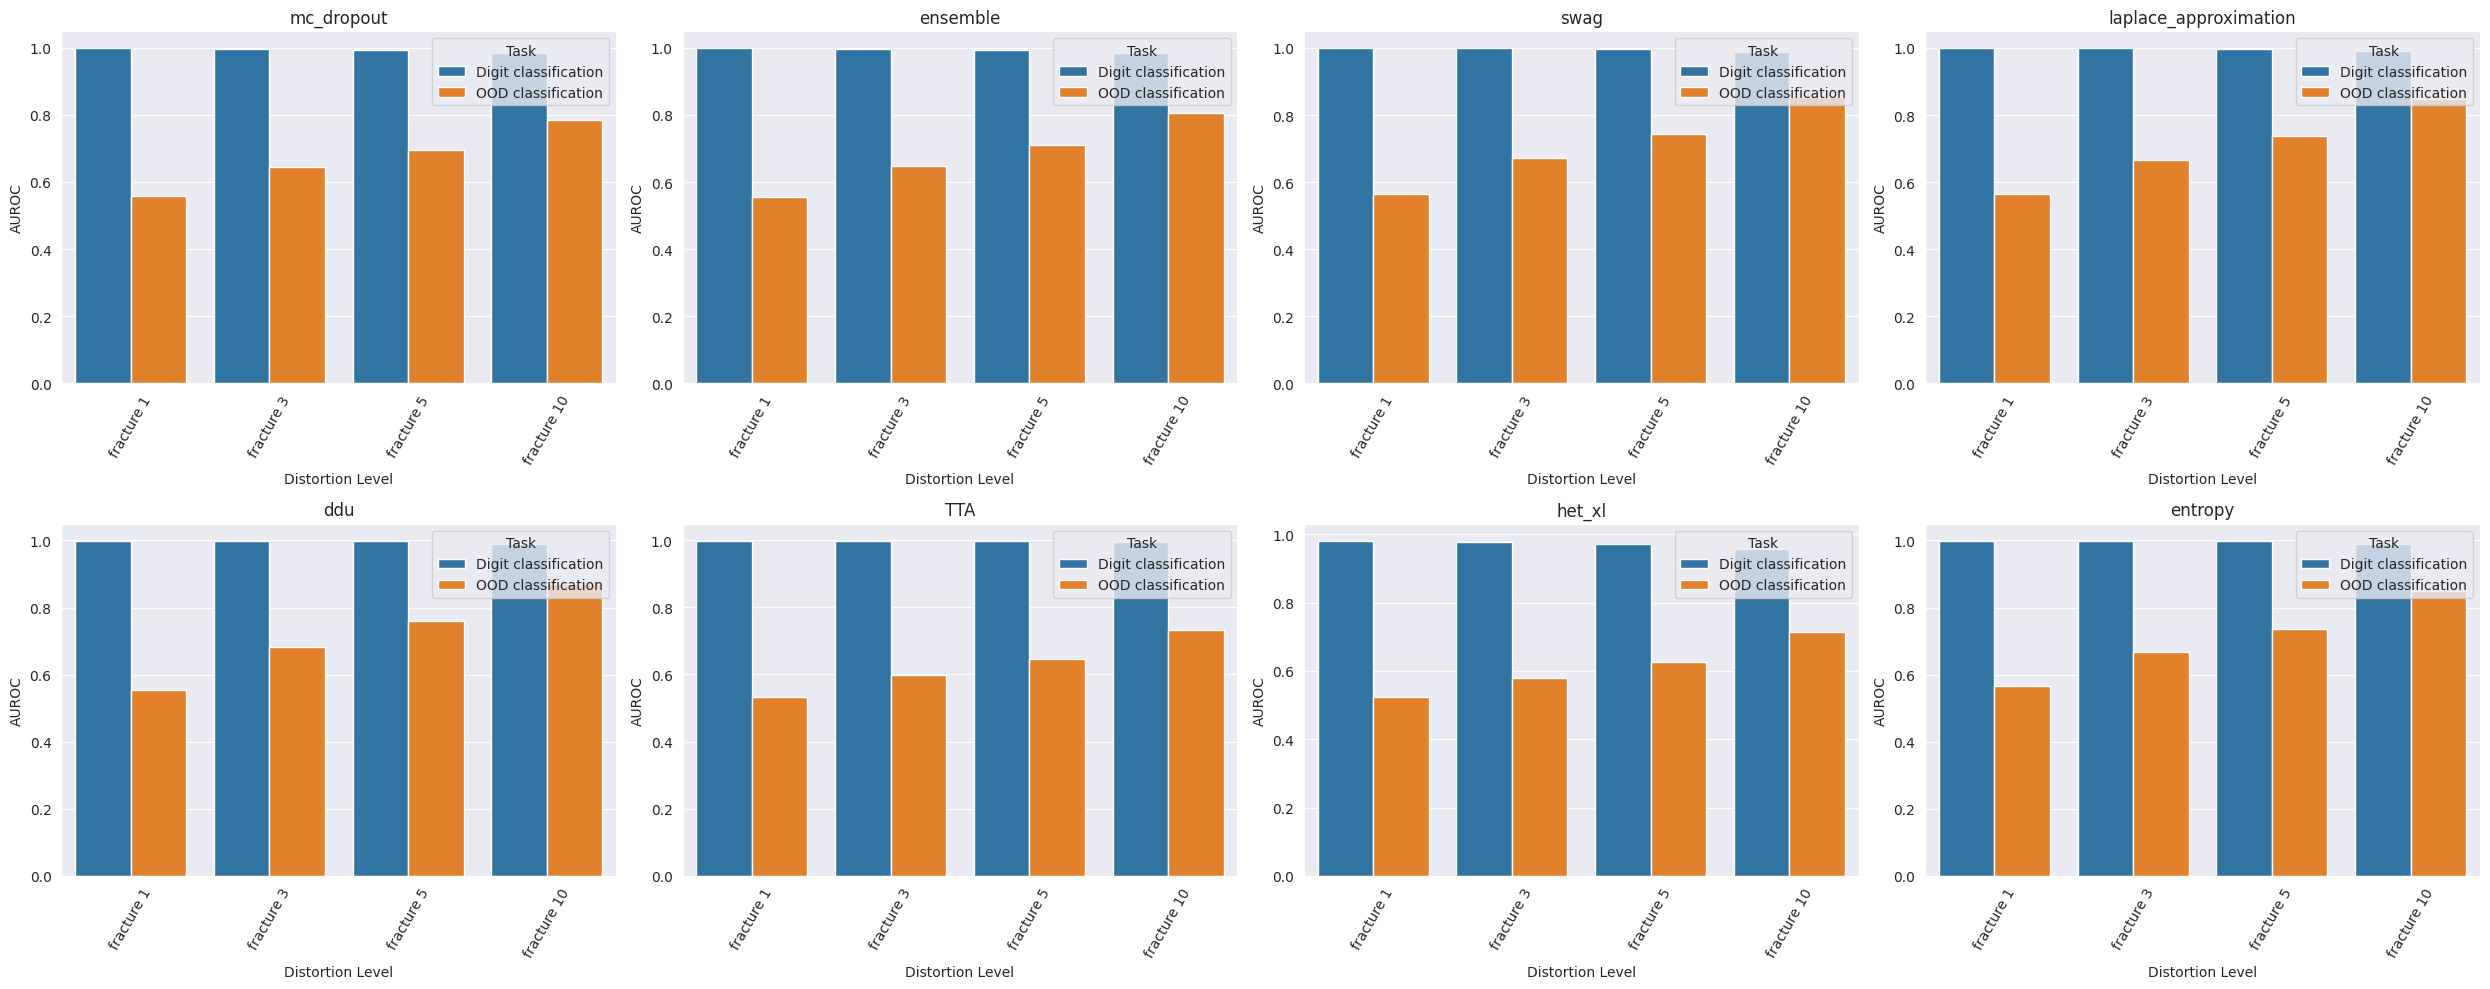

In [8]:
for dist_type in list(test_dl.keys()):
    uncertainty_type = 'total_uncertainty'
    fig, ax = plt.subplots(2,4, figsize=(25,10))
    for i, m in enumerate(methods[uncertainty_type]):
        id_uncertainty = pickle.load(open(os.path.join(root, m, 'result', 'id_uncertainty.pkl'), 'rb'))
        rows = []
        for distortion in test_dl[dist_type].keys():
            data = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}.pkl'), 'rb'))
            predictions = data["predictions"].numpy()
            if len(predictions.shape) > 2:
                predictions = np.mean(predictions, axis=0)
            gt = data["ground_truth"].numpy()

            auroc = roc_auc_score(gt, predictions, multi_class='ovr')
            rows.append({
                    'Distortion Level': distortion,
                    'AUROC': auroc,
                    'Task': 'Digit classification'
                })

            uncertainty = data[uncertainty_type].numpy()
            true_labels = np.concatenate(
                [np.zeros_like(id_uncertainty[uncertainty_type]), np.ones_like(uncertainty)])
            uncertainty_scores = np.concatenate(
                [id_uncertainty[uncertainty_type], uncertainty])  # higher = more OOD-like
            auroc = roc_auc_score(true_labels, uncertainty_scores)
            rows.append({
                'Distortion Level': distortion,
                'AUROC': auroc,
                'Task': 'OOD classification'
            })

        res = pd.DataFrame(rows)
        sns.barplot(x="Distortion Level", y="AUROC", hue='Task', data=res, ax=ax[i//4, i%4])
        ax[i//4, i%4].tick_params(axis='x', rotation=60)
        ax[i//4, i%4].set_title(m)
    plt.tight_layout()
    plt.savefig(os.path.join(root, 'common', 'plots', f'auroc_{dist_type}.pdf'))
    plt.show()

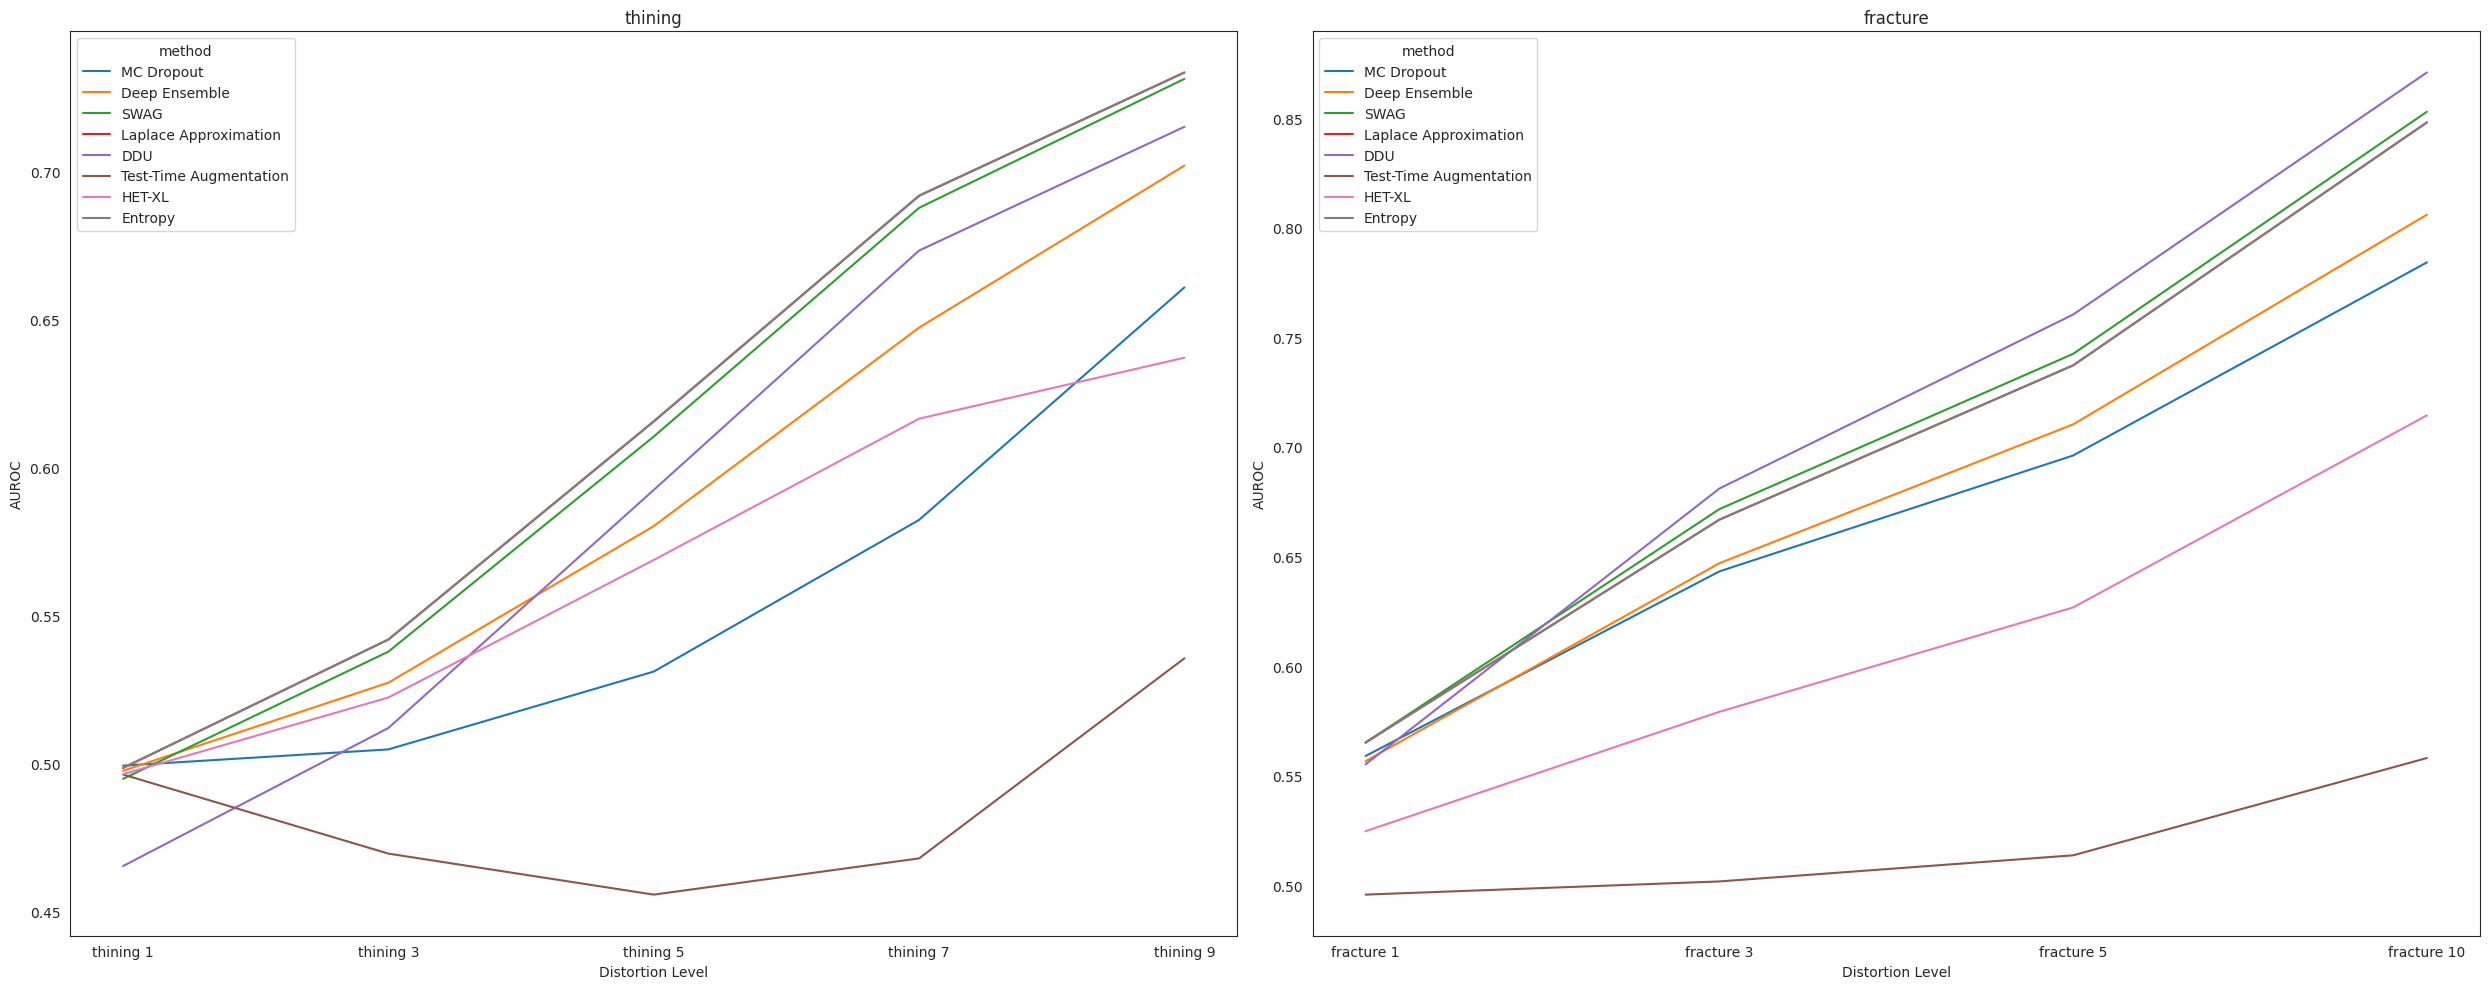

In [30]:
fig, ax = plt.subplots(1,len(test_dl.keys()), figsize=(25,10))
for i,dist_type in enumerate(list(test_dl.keys())):
    uncertainty_type = 'total_uncertainty'
    rows = []
    for j, m in enumerate(methods[uncertainty_type]):
        id_uncertainty = pickle.load(open(os.path.join(root, m, 'result', 'id_uncertainty.pkl'), 'rb'))
        for distortion in test_dl[dist_type].keys():
            data = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}.pkl'), 'rb'))
            predictions = data["predictions"].numpy()
            if len(predictions.shape) > 2:
                predictions = np.mean(predictions, axis=0)
            gt = data["ground_truth"].numpy()

            auroc = roc_auc_score(gt, predictions, multi_class='ovr')
            rows.append({
                    'Distortion Level': distortion,
                    'AUROC': auroc,
                    'Task': 'Digit classification',
                    'method': m
                })

            uncertainty = data[uncertainty_type].numpy()
            true_labels = np.concatenate(
                [np.zeros_like(id_uncertainty[uncertainty_type]), np.ones_like(uncertainty)])
            uncertainty_scores = np.concatenate(
                [id_uncertainty[uncertainty_type], uncertainty])  # higher = more OOD-like
            auroc = roc_auc_score(true_labels, uncertainty_scores)
            rows.append({
                'Distortion Level': distortion,
                'AUROC': auroc,
                'Task': 'OOD classification',
                'method': legened_map[m]
            })

    res = pd.DataFrame(rows)
    sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res[res['Task']=='OOD classification'], ax=ax[i], palette=palette_dict)
    # ax[i].tick_params(axis='x', rotation=60)
    ax[i].set_title(dist_type)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'auroc_line.pdf'))
plt.show()

In [ ]:
data = pickle.load(open('/home/msafa/PhD/benchmark/experiments/morpho_mnist_result/ddu/result/testset_uncertainty_fracture_fracture 1.pkl', 'rb'))

In [ ]:
data['predictions'].shape

In [ ]:
(data['ground_truth'] == data['predicted_labels']).sum()

In [ ]:
roc_auc_score(data['ground_truth'], data['predictions'], multi_class='ovr')

## aleatoric

### trend

In [4]:
root = ('/home/msafa/PhD/benchmark/experiments/mnist_aleatoric_result')

In [5]:
train_dl, val_dl = load_mnist_blur_data('/home/msafa/PhD/morpho/Morpho-MNIST/data')

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(25,10))
for i, m in enumerate(methods):
    rows = []
    for distortion in train_dl.keys():
        data = pickle.load(open(os.path.join(root, m, 'result', f'validset_uncertainty_{distortion}.pkl'), 'rb'))
        for u_type in ['epistemic_uncertainty']:
            rows.append({
                'uncertainty': u_type,
                'Uncertainty Score': data[u_type].numpy(),
                'training size': distortion,
            })
    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="training size", y="Uncertainty Score", data=res, ax=ax[i//4, i%4])
    ax[i//4, i%4].tick_params(axis='x', rotation=60)
    ax[i//4, i%4].set_title(m)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'trend_epistemic.pdf'))
plt.show()

In [ ]:
for k in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    all_uncertainty={}
    for method in methods:
        all_uncertainty[method] = {}
        for distortion in train_dl.keys():
            data = pickle.load(open(os.path.join(root, method, 'result', f'validset_uncertainty_{distortion}.pkl'), 'rb'))
            all_uncertainty[method][distortion] = data

    plot = aleatoric_trend(all_uncertainty, uncertainty_type=k)
    # plot.title(k)
    plot.savefig(os.path.join(root, 'common', 'plots', f'{k}_aleatoric_trend.pdf'))
    # plot.close()

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(25,8))
for i, k in enumerate(['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']):
    rows = []
    for m in methods[k]:
        for distortion in train_dl.keys():
            data = pickle.load(open(os.path.join(root, m, 'result', f'validset_uncertainty_{distortion}.pkl'), 'rb'))
            rows.append({
                'uncertainty': k,
                'Uncertainty Score': data[k].numpy(),
                'Ambiguity Level': distortion,
                'method': legened_map[m]
            })
    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    sns.lineplot(x="Ambiguity Level", y="Uncertainty Score", data=res, hue='method', ax=ax[i], palette=palette_dict)
    # ax[i].tick_params(axis='x', rotation=60)
    ax[i].set_xticklabels([f'{x.get_text()}%' for x in ax[i].get_xticklabels()])
    ax[i].set_title(k)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'aleatoric_trend.pdf'))
plt.show()

### blur

In [3]:
root = ('/home/msafa/PhD/benchmark/experiments/mnist_blur_result')


In [4]:
train_dl, val_dl , test_dl = load_data_blurred('/home/msafa/PhD/morpho/Morpho-MNIST/data')

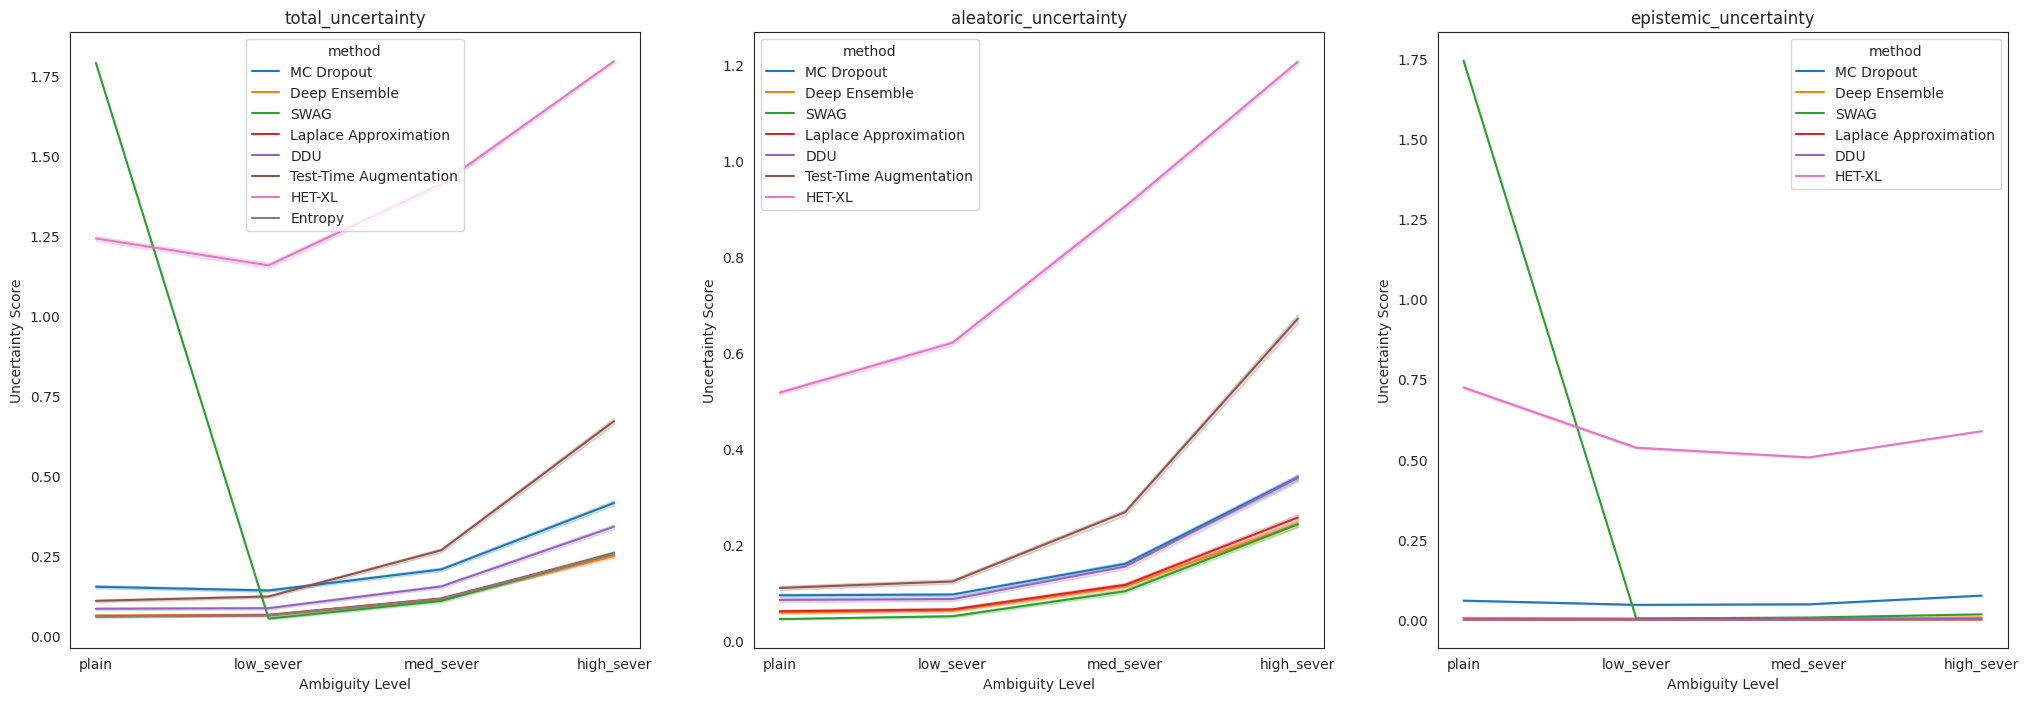

In [12]:
fig, ax = plt.subplots(1,3, figsize=(25,8))
sns.set_style('white')
order = ['plain', 'low_sever', 'med_sever', 'high_sever']
for i, m in enumerate(methods):
    rows = []
for i, k in enumerate(['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']):
    rows = []
    for method in methods[k]:
        for distortion in order:
            data = pickle.load(open(os.path.join(root, method, 'result', f'testset_uncertainty_{distortion}.pkl'), 'rb'))
            rows.append({
                'Uncertainty Score': data[k].numpy(),
                'Ambiguity Level': distortion,
                'method': legened_map[method]
            })

    res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
    # res["Ambiguity Level"] = pd.Categorical(
    # res["Ambiguity Level"],
    #     categories=order,
    #     ordered=True
    # )
    # res = res.sort_values(['method', "Ambiguity Level"])
    sns.lineplot(x="Ambiguity Level", y="Uncertainty Score", data=res, hue='method', ax=ax[i], palette=palette_dict,)
        # hue_order=legened_map.values(),)
    ax[i].set_title(k)
    # ax[i].set_xticks(order)
plt.savefig(os.path.join(root, 'common', 'plots', f'blur_trend.pdf'))
plt.show()
plt.close()

## Misclassification

In [16]:
train_dl, val_dl, test_dl = load_data('/home/msafa/PhD/morpho/Morpho-MNIST/data')

In [17]:
root = '/home/msafa/PhD/benchmark/experiments/morpho_mnist_result'

mc_dropout 10000
ensemble 10000
swag 10000
laplace_approximation 10000
ddu 10000
TTA 10000
het_xl 10000
entropy 10000


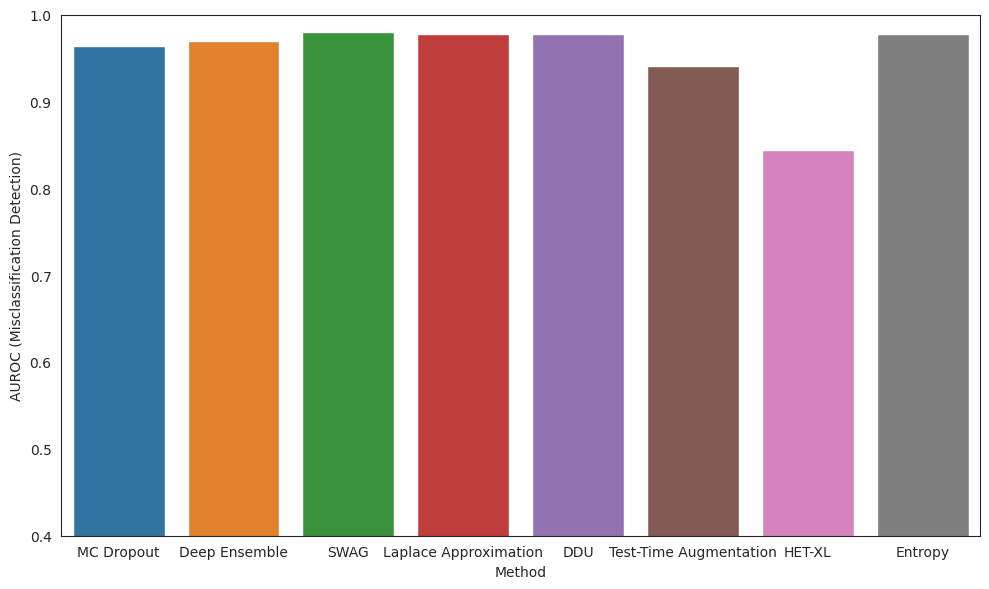

In [19]:
rows = []
uncertainty_type = 'total_uncertainty'
for m in methods[uncertainty_type]:
    data = pickle.load(open(os.path.join(root, m, 'result', f'id_uncertainty.pkl'), 'rb'))
    print(m, len(data['ground_truth']))
    uncertainty = data[uncertainty_type].detach().cpu().numpy()
    true_labels = (data['predicted_labels'] != data['ground_truth']).detach().cpu().numpy()

    auroc = roc_auc_score(true_labels, uncertainty)

    rows.append({
        'Method': legened_map[m],
        'AUROC': auroc,
    })

res = pd.DataFrame(rows)

plt.figure(figsize=(10,6))
sns.set_palette("Set1")

ax = sns.barplot(x="Method", y="AUROC", hue="Method", legend=False, data=res, palette=palette_dict)
ax.set_ylabel("AUROC (Misclassification Detection)")
# ax.tick_params(axis='x', rotation=45)
ax.set_ylim([0.4,1.])

plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', 'misclassification.pdf'))
plt.show()

# ISIC

In [3]:
root = '/home/msafa/PhD/benchmark/experiments/isic_result'

In [4]:

_, train_dl, val_dl, test_dl = next(load_isic_data('/home/msafa/PhD/isic/MILK'))

In [5]:

for dist_tyep in test_dl.keys():
    tmp = []
    for dist_level in test_dl[dist_tyep].keys():
        tmp.append(len(test_dl[dist_tyep][dist_level].dataset.labels))
        print(dist_tyep, dist_level,len(test_dl[dist_tyep][dist_level].dataset.labels))
    print(dist_tyep, np.sum(tmp))

age under 30 52
age 35 23
age 40 46
age 45 59
age 50 88
age 55 89
age 60 116
age 65 143
age 70 148
age 75 124
age 80 63
age 85 57
age 1008
skin tone tone 1 22
skin tone tone 2 89
skin tone tone 3 604
skin tone tone 4 203
skin tone tone 5 90
skin tone 1008
hair level 1 107
hair level 2 241
hair level 3 427
hair level 4 233
hair 1008
drop level 1 528
drop level 2 214
drop level 3 266
drop 1008
ink level 1 416
ink level 2 319
ink level 3 176
ink level 4 97
ink 1008


In [6]:
for k in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    for method in methods['total_uncertainty']:
        all_uncertainty={}
        for dist_type in test_dl.keys():
            all_uncertainty[dist_type] = {}
            for distortion in test_dl[dist_type].keys():
                data = []
                for i in range(5):
                    data.append(pickle.load(open(os.path.join(root, method, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{i}.pkl'), 'rb')))
                data = {key: np.concatenate([d[key].numpy() for d in data], axis=0) for key in data[0].keys()}
                all_uncertainty[dist_type][distortion] = data

        plot = moving_out_of_distribution(all_uncertainty, uncertainty_type=k)
        plot.savefig(os.path.join(root, method, 'plots', f'moving_out_of_distribution_{k}.pdf'))
        plot.close()

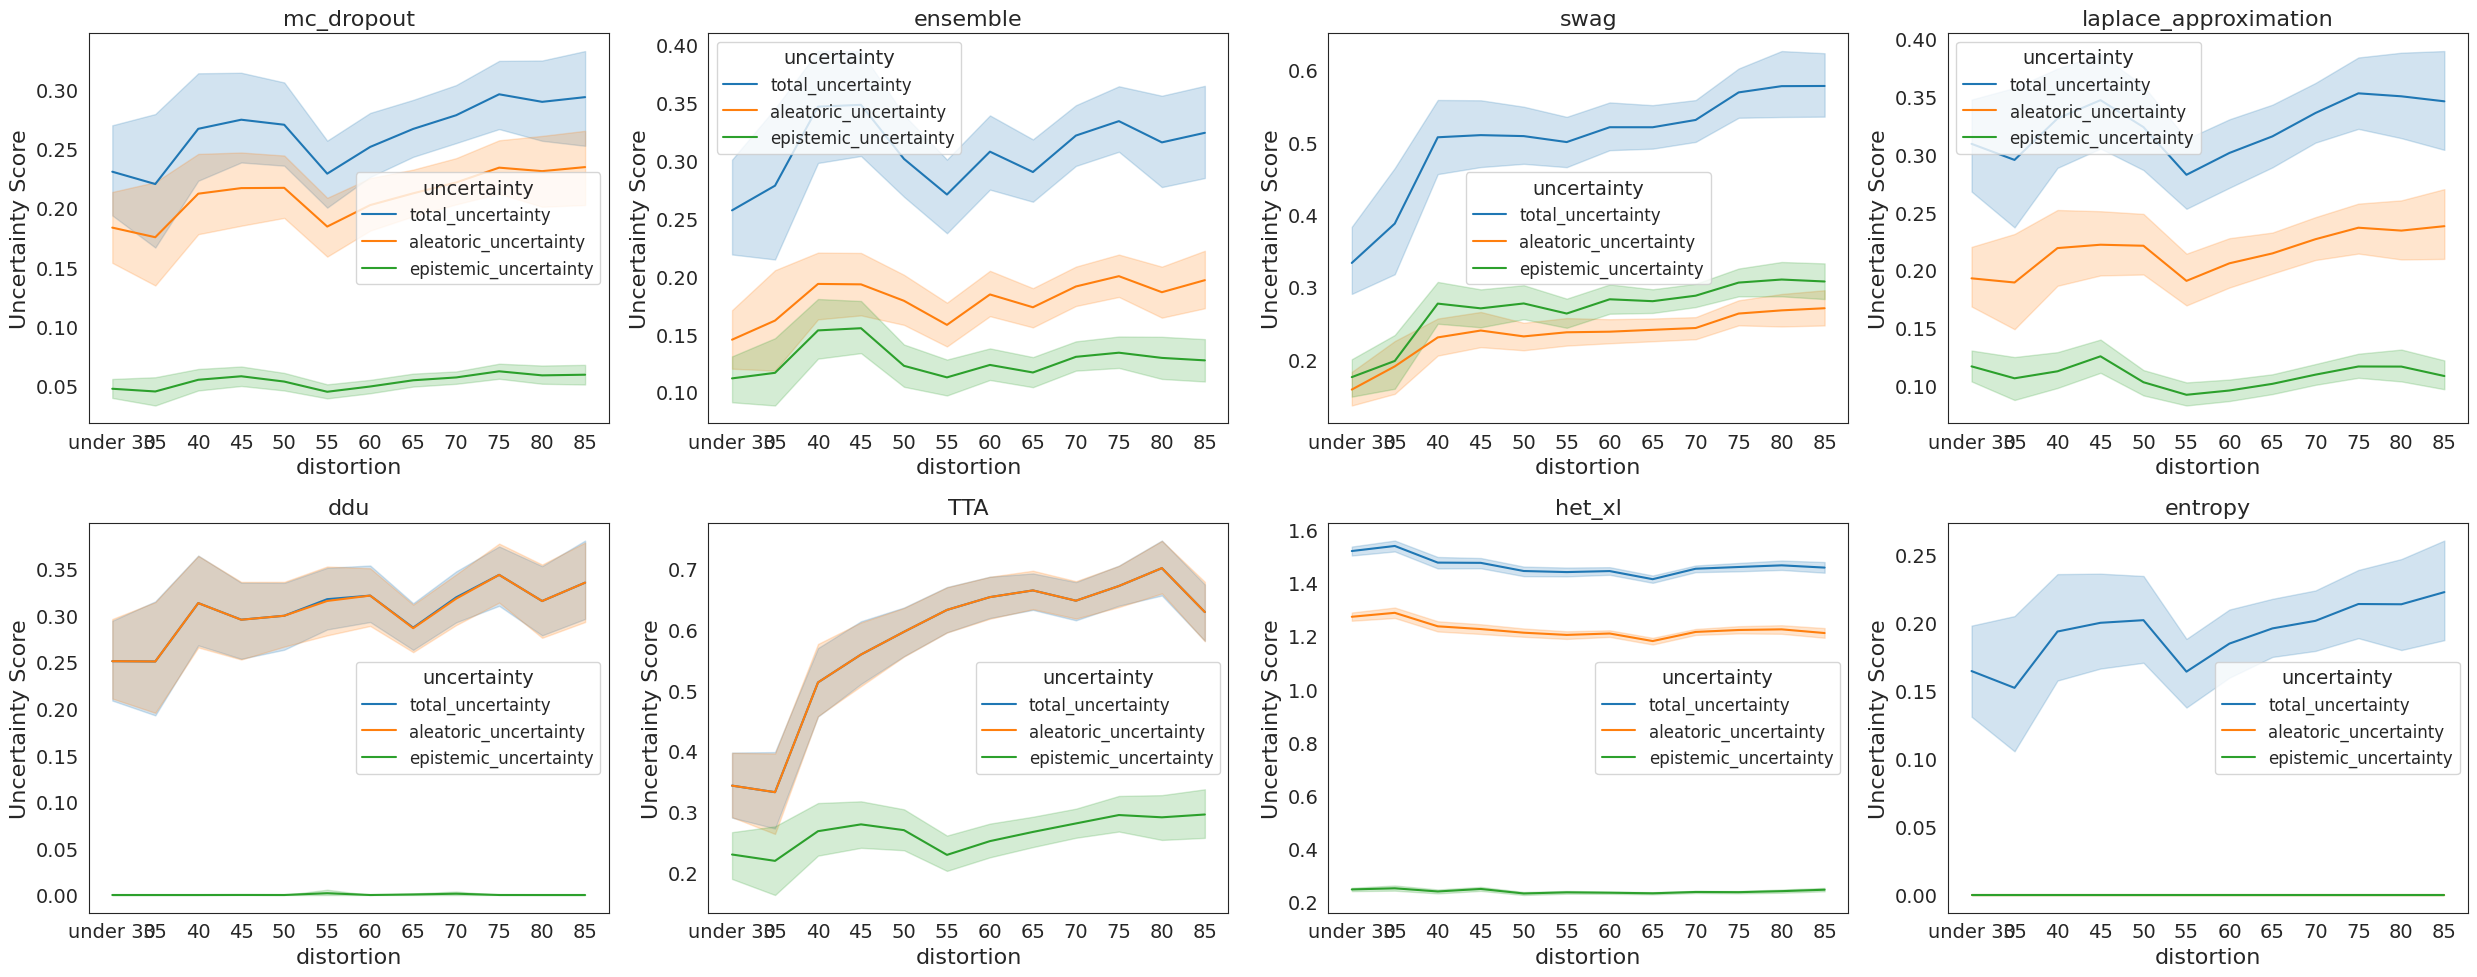

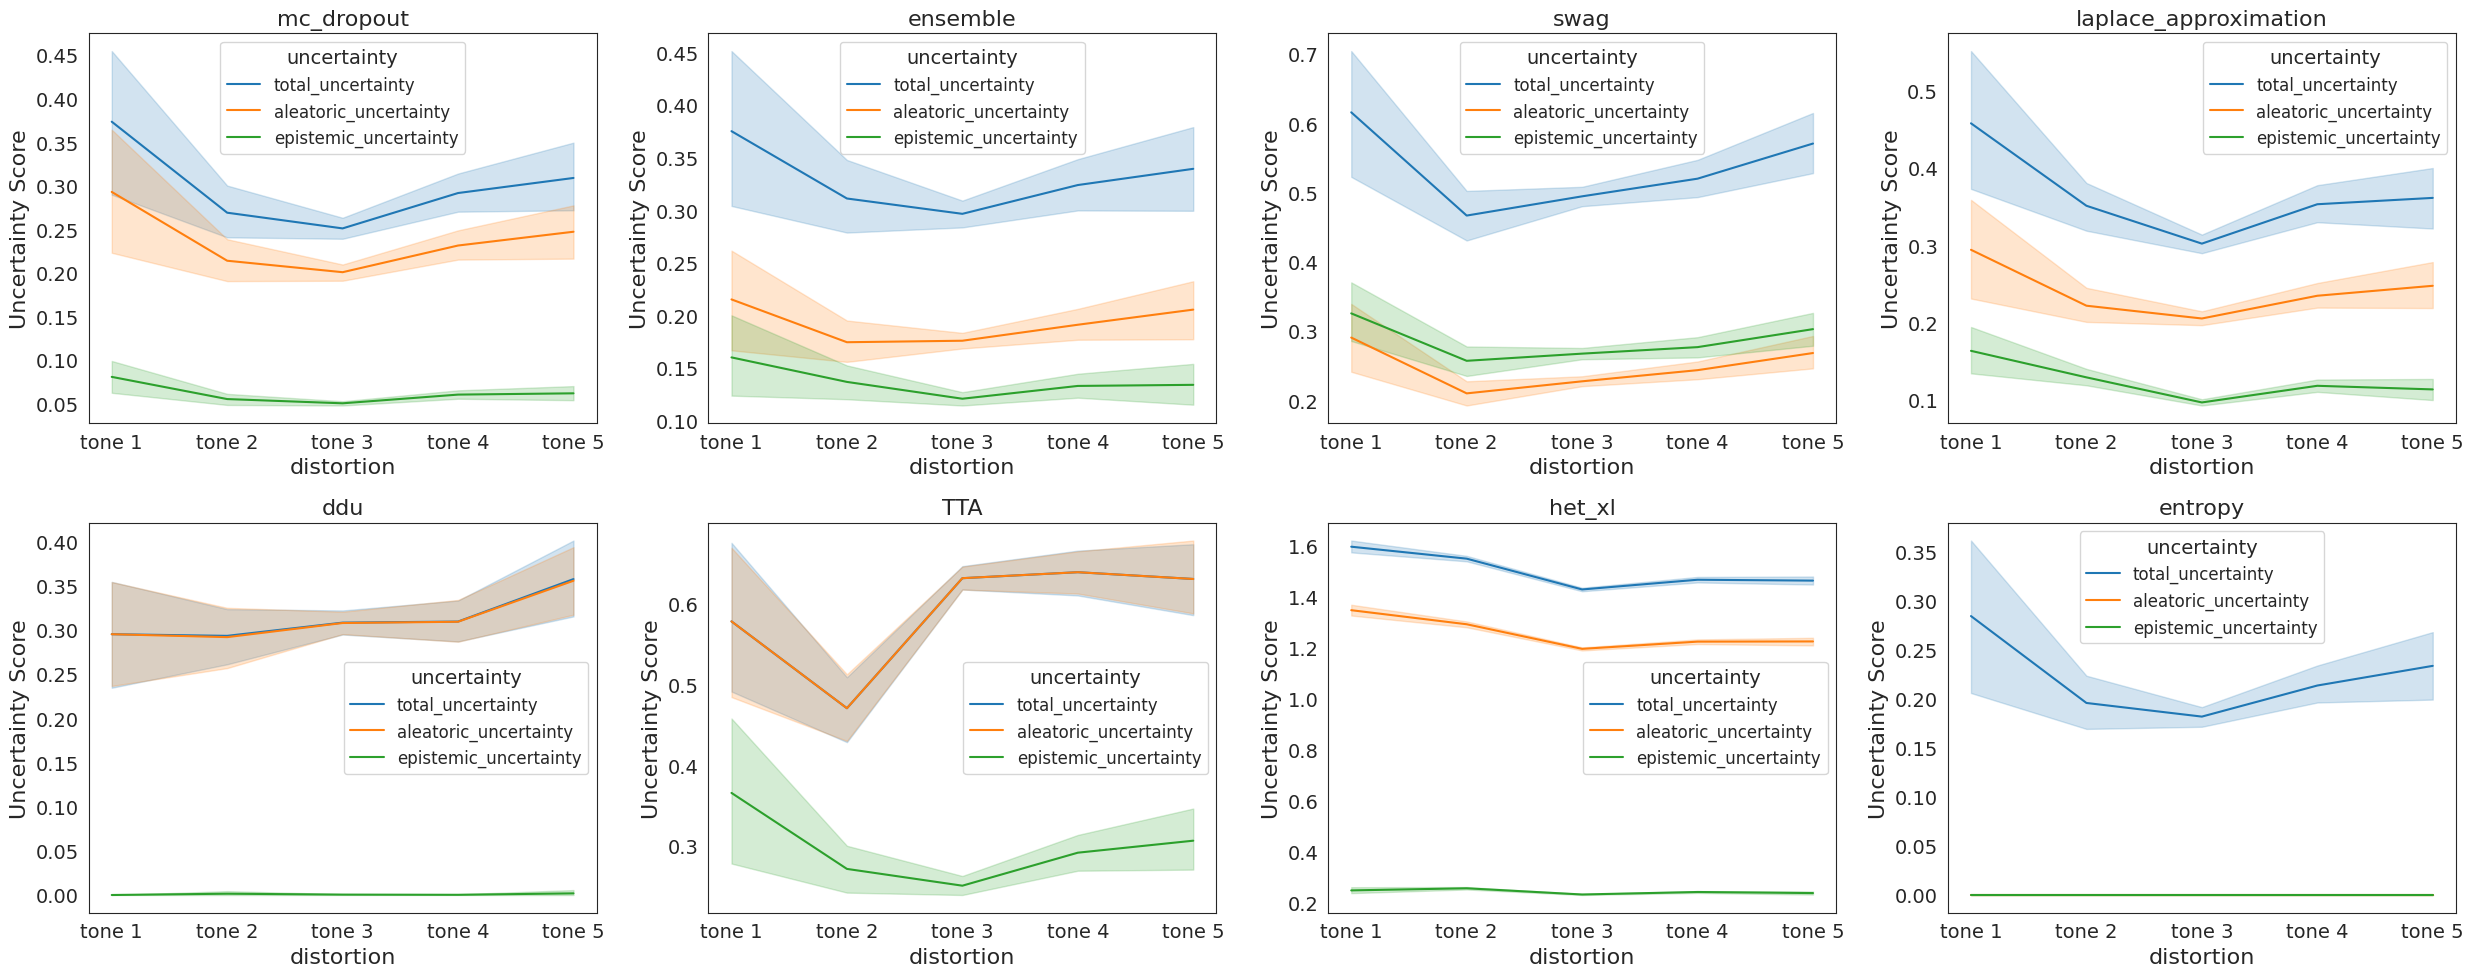

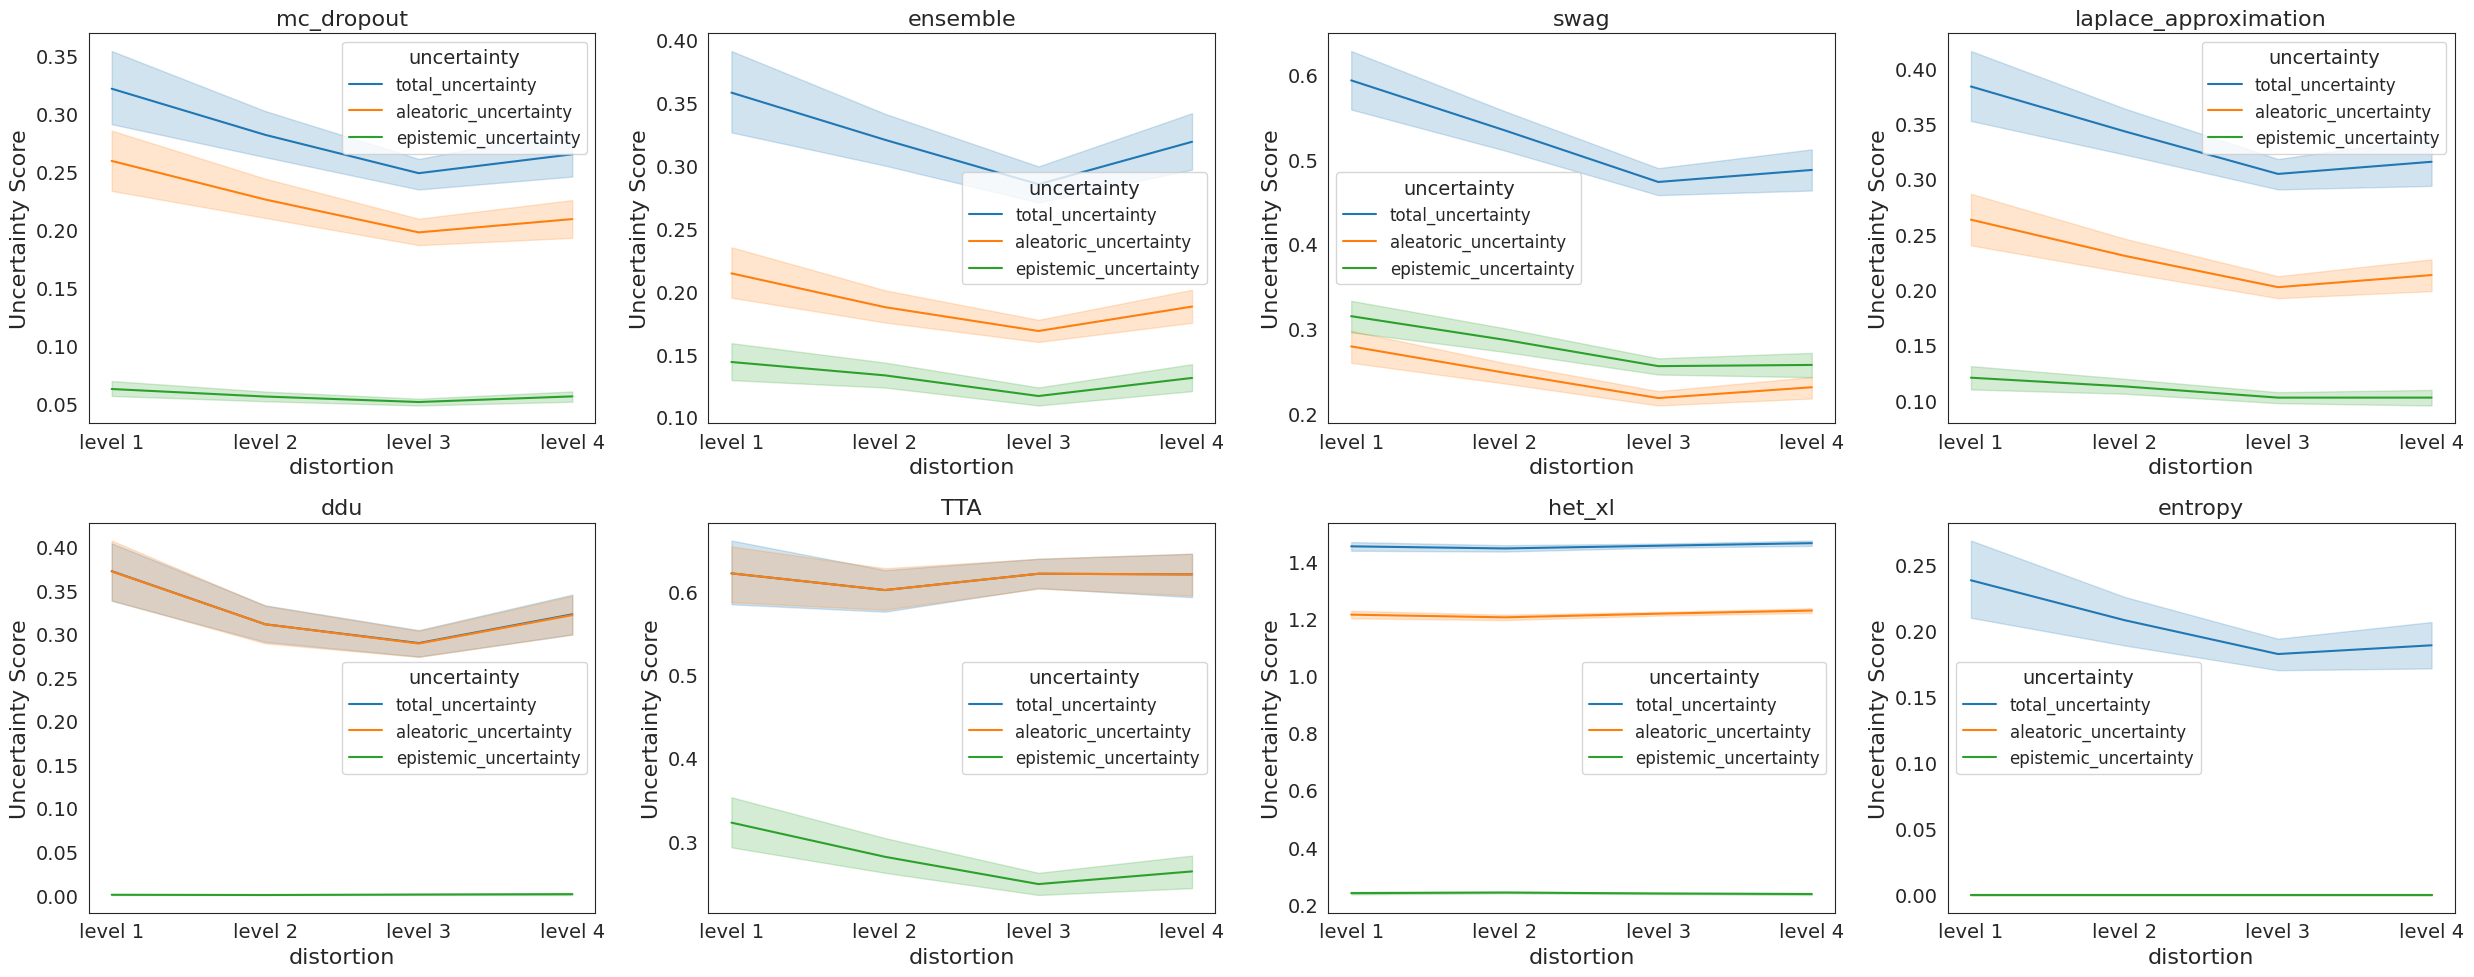

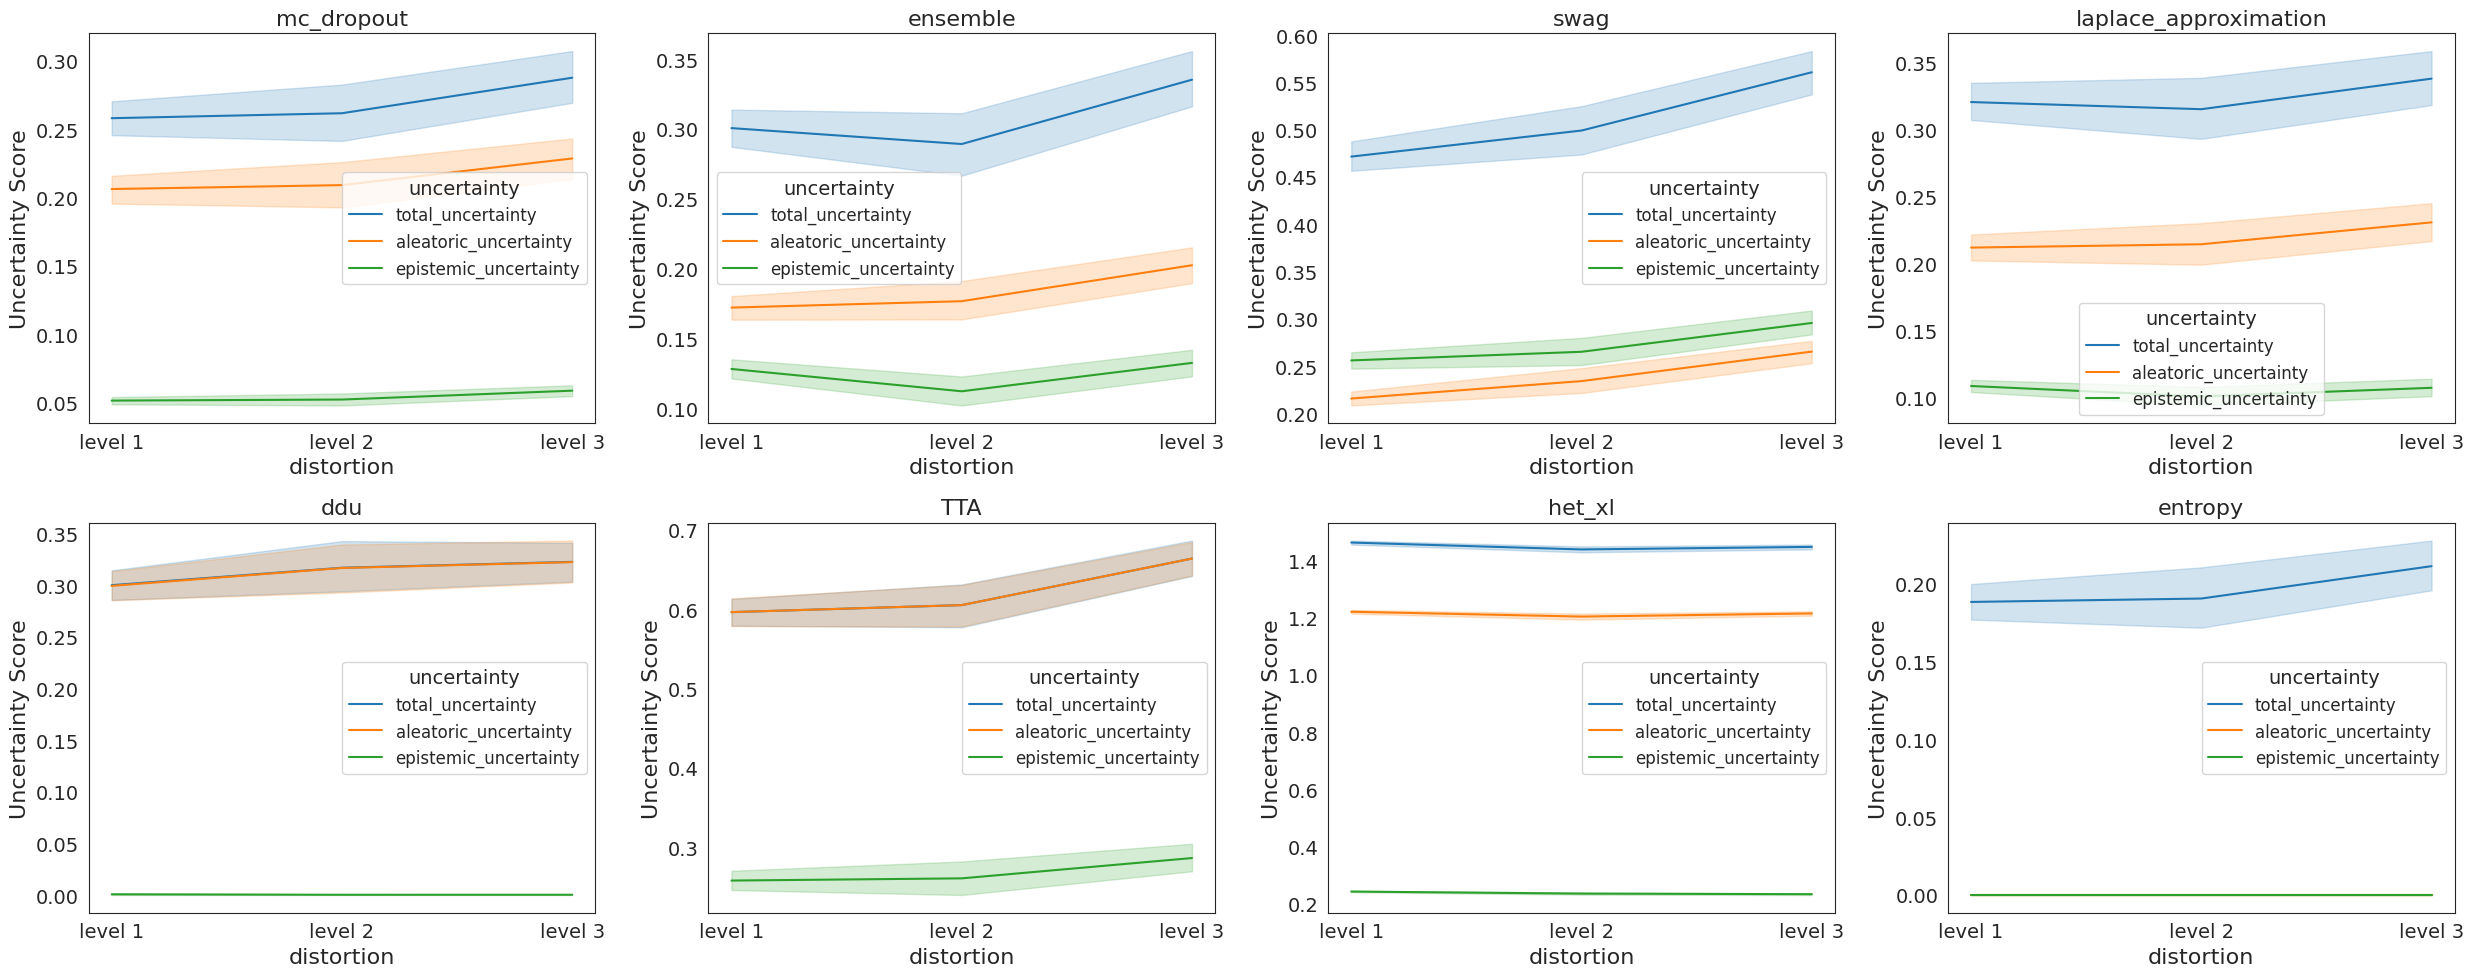

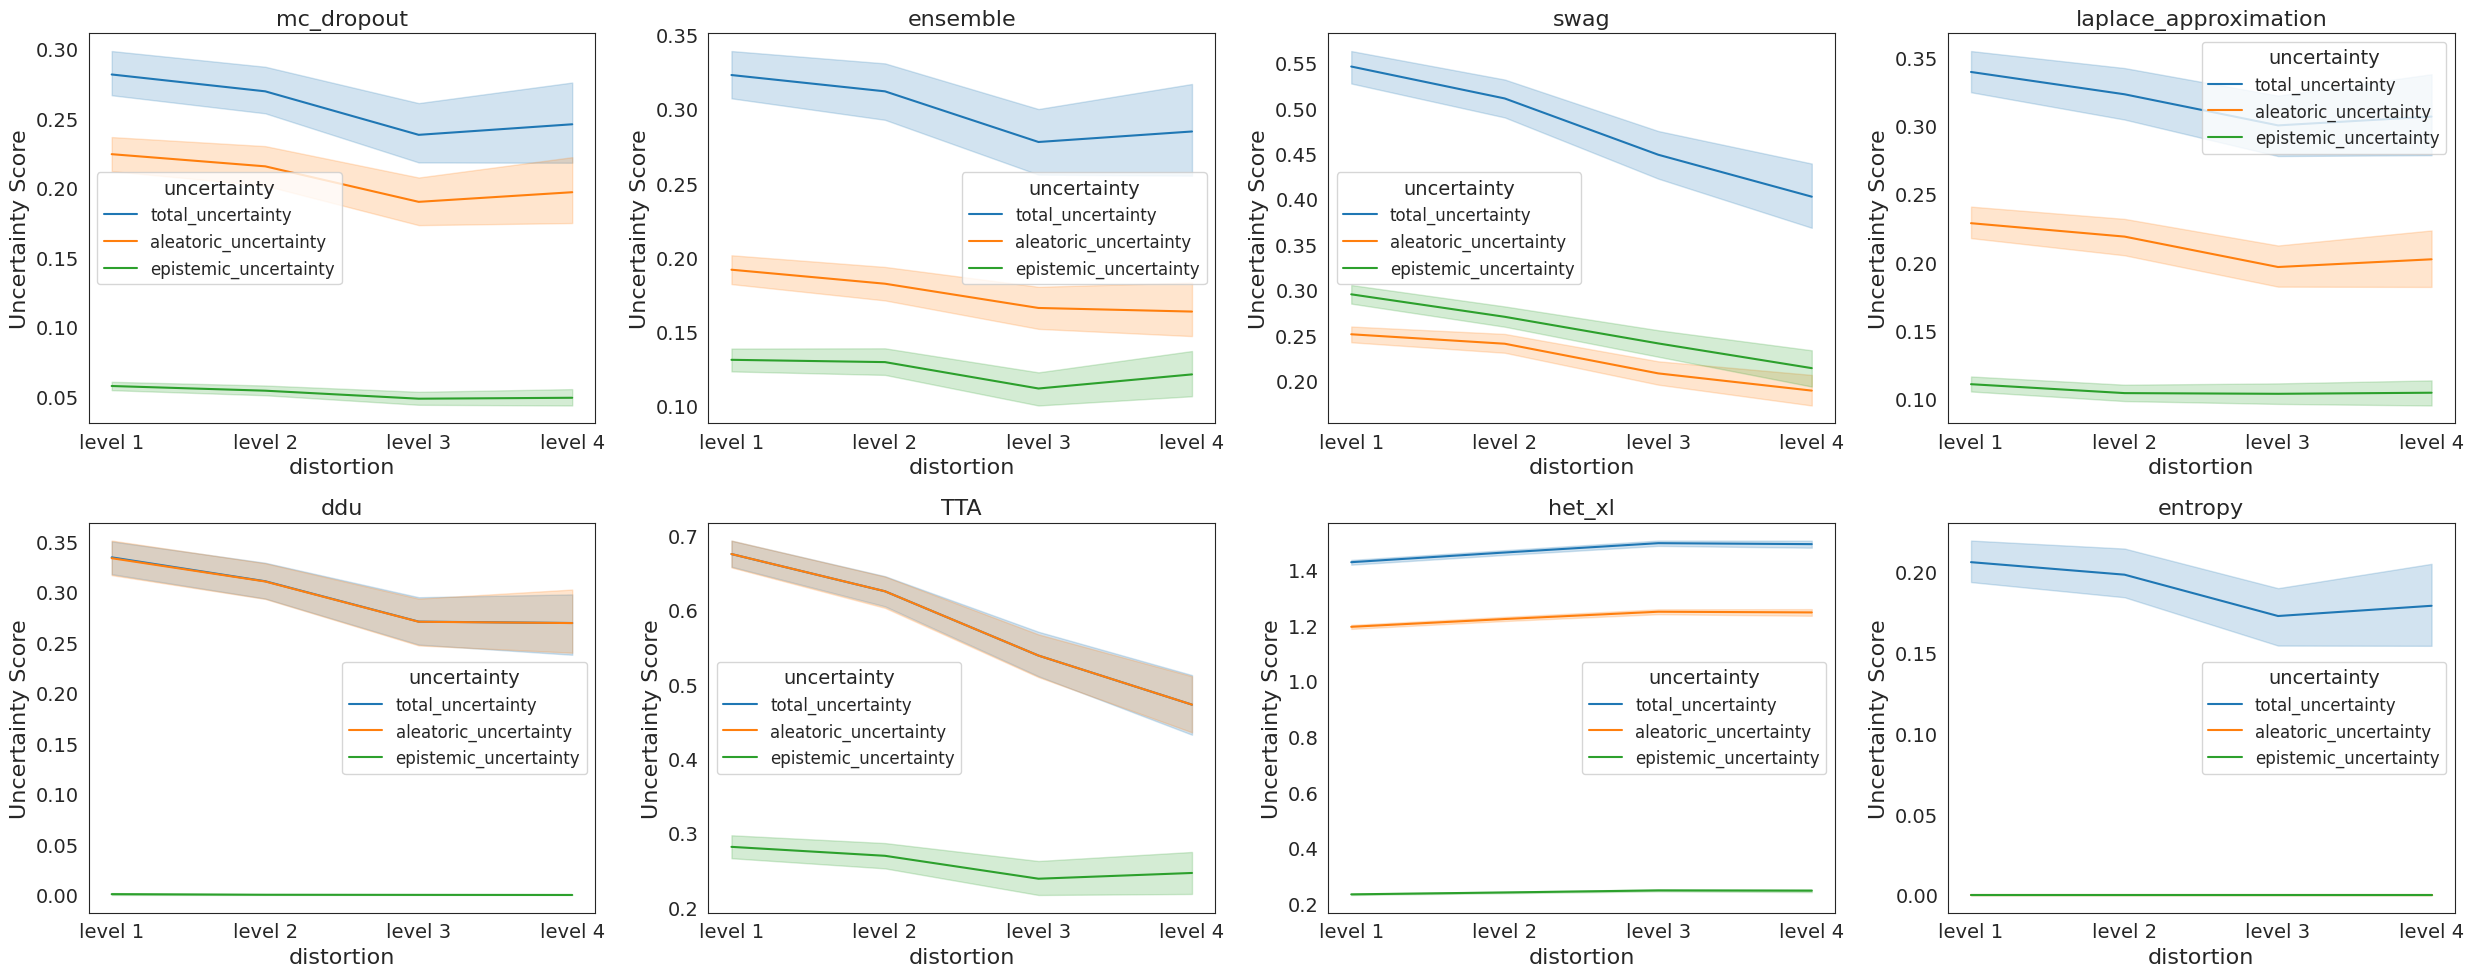

In [5]:
sns.set_style('white')
plt.rcParams.update({"font.size": 14, "xtick.labelsize": 14, "ytick.labelsize": 14, "axes.labelsize": 16, "axes.titlesize": 16, "legend.fontsize": 12})
dist_type = list(test_dl.keys())[1]
for dist_type in list(test_dl.keys()):
    fig, ax = plt.subplots(2,4, figsize=(25,10))
    for i, m in enumerate(methods['total_uncertainty']):
        rows = []
        for distortion in test_dl[dist_type].keys():
            data = []
            for j in range(5):
                data.append(pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{j}.pkl'), 'rb')))
            data = {key: np.concatenate([d[key].numpy() for d in data], axis=0) for key in data[0].keys()}

            for u_type in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
                rows.append({
                    'uncertainty': u_type,
                    'Uncertainty Score': data[u_type],
                    'distortion': distortion,
                })
        res = pd.DataFrame(rows).explode('Uncertainty Score').reset_index(drop=True)
        sns.lineplot(x="distortion", y="Uncertainty Score", hue='uncertainty', data=res, ax=ax[i//4, i%4])
        # ax[i//4, i%4].tick_params(axis='x', rotation=60)
        ax[i//4, i%4].set_title(m)
    plt.tight_layout()
    plt.savefig(os.path.join(root, 'common', 'plots', f'moving_out_of_distribution_{dist_type}.pdf'))
    plt.show()

In [11]:
for k in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    all_uncertainty={}
    for dist_type in test_dl.keys():
        all_uncertainty[dist_type] = {}
        for method in methods[k]:
            all_uncertainty[dist_type][method] = {}
            for distortion in test_dl[dist_type].keys():
                data = []
                for i in range(5):
                    data.append(pickle.load(open(os.path.join(root, method, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{i}.pkl'), 'rb')))
                data = {key: np.concatenate([d[key].numpy() for d in data], axis=0) for key in data[0].keys()}
                all_uncertainty[dist_type][method][distortion] = data

    plot = moving_out_of_distribution_compare(all_uncertainty, uncertainty_type=k, legend_map=legened_map, palette=palette_dict)
    # plot.axis('off')
    # plot.grid(False)
    plot.savefig(os.path.join(root, 'common', 'plots', f'moving_out_of_distribution_{k}.pdf'), transparent=True)
    plot.close()

under 30 [0 3 4 5]
[0 3 4 5]
35 [0 2 3 4 5]
[0 2 3 4 5]
40 [0 1 2 3 4 5]
[0 1 2 3 4 5]
45 [0 1 2 3 4 5]
[0 1 2 3 4 5]
50 [0 1 2 3 4 5]
[0 1 2 3 4 5]
55 [0 1 2 3 4 5]
[0 1 2 3 4 5]
60 [0 1 2 3 4 5]
[0 1 2 3 4 5]
65 [0 1 2 3 4 5]
[0 1 2 3 4 5]
70 [0 1 2 3 4 5]
[0 1 2 3 4 5]
75 [0 1 2 3 4 5]
[0 1 2 3 4 5]
80 [0 1 2 3 4 5]
[0 1 2 3 4 5]
85 [0 1 2 3 4 5]
[0 1 2 3 4 5]
   Distortion Level     AUROC                    Task
0          under 30  0.864706  Disease classification
2                35  0.861662  Disease classification
4                40  0.890693  Disease classification
6                45  0.906794  Disease classification
8                50  0.908422  Disease classification
10               55  0.915465  Disease classification
12               60  0.897952  Disease classification
14               65  0.898013  Disease classification
16               70  0.913179  Disease classification
18               75  0.891091  Disease classification
20               80  0.895058  Disease c

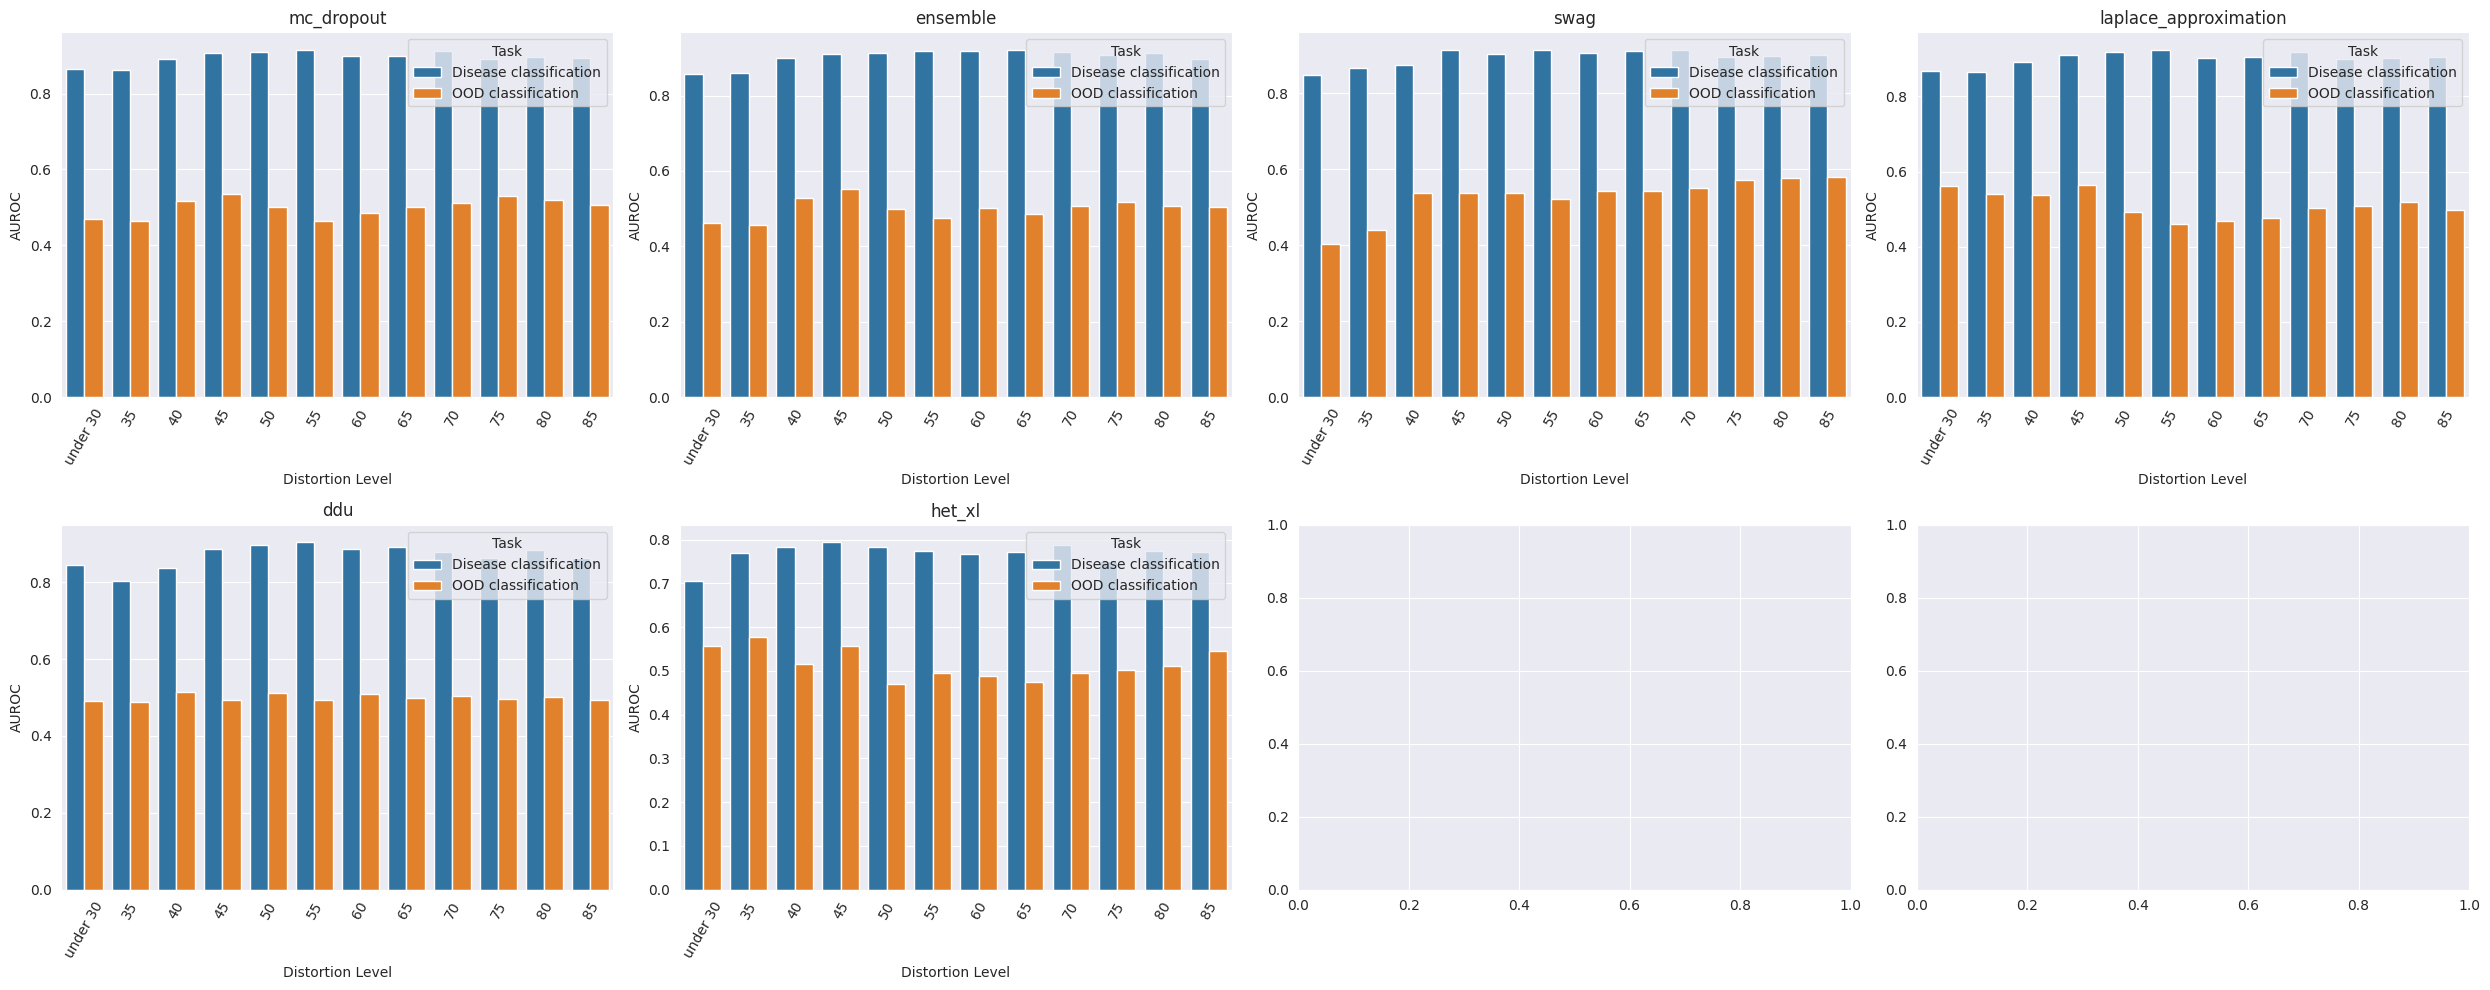

tone 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 5 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0           tone 1  0.917192  Disease classification
2           tone 2  0.921861  Disease classification
4           tone 3  0.906968  Disease classification
6           tone 4  0.894520  Disease classification
8           tone 5  0.895388  Disease classification
tone 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
tone 5 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0           tone 1  0.937758  Disease classification
2           tone 2  0.932351  Disease classification
4           tone 3  0.919598  Disease classification
6           tone 4  0.903869  Disease classification
8           tone 5  0.888229  Disease classification
tone 1 [0. 1. 

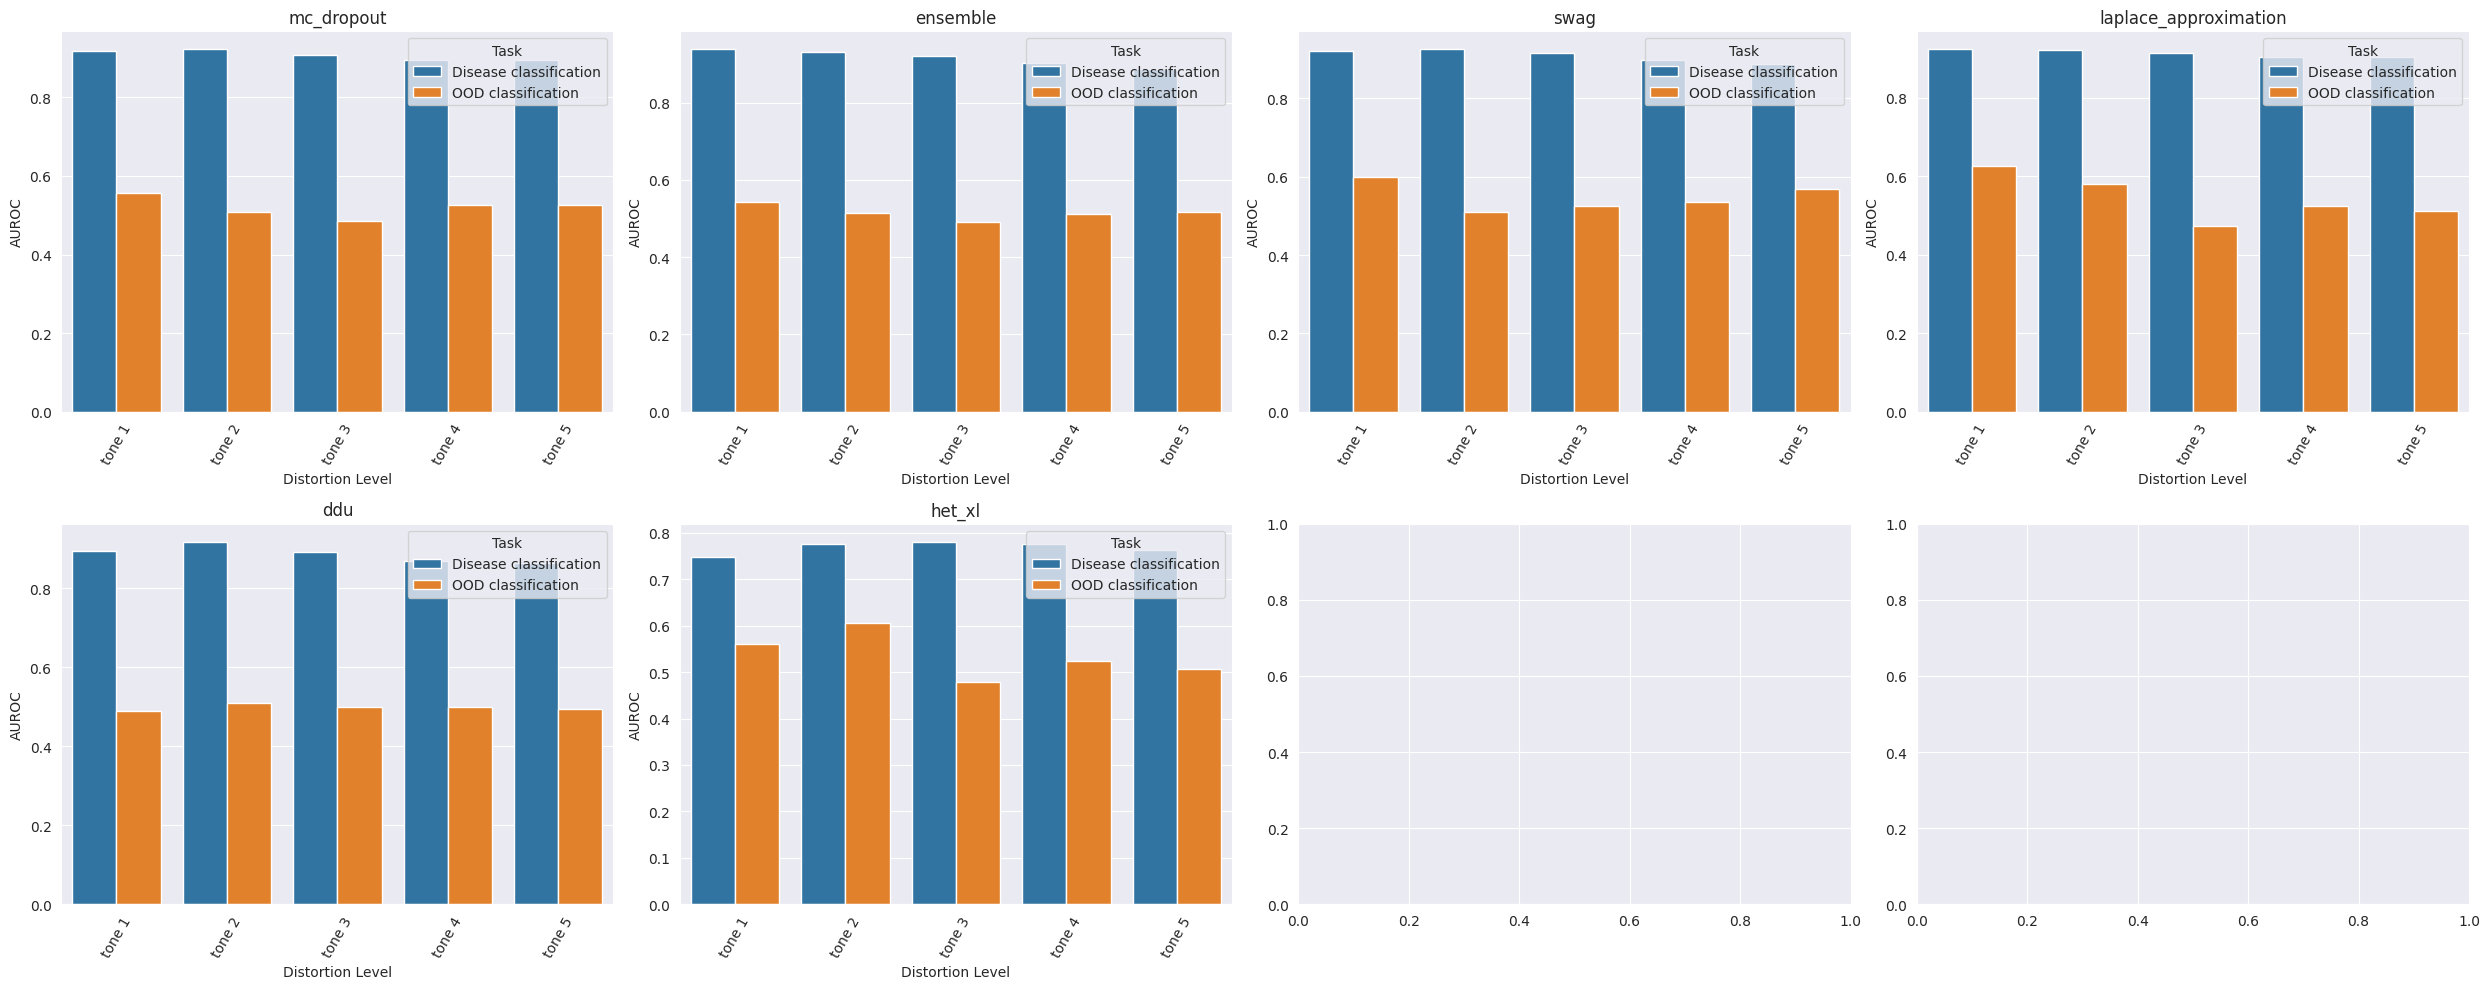

level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.899246  Disease classification
2          level 2  0.909524  Disease classification
4          level 3  0.910474  Disease classification
6          level 4  0.892428  Disease classification
level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.913050  Disease classification
2          level 2  0.919544  Disease classification
4          level 3  0.921363  Disease classification
6          level 4  0.905177  Disease classification
level 1 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 2 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 3 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 4 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
  Distortion L

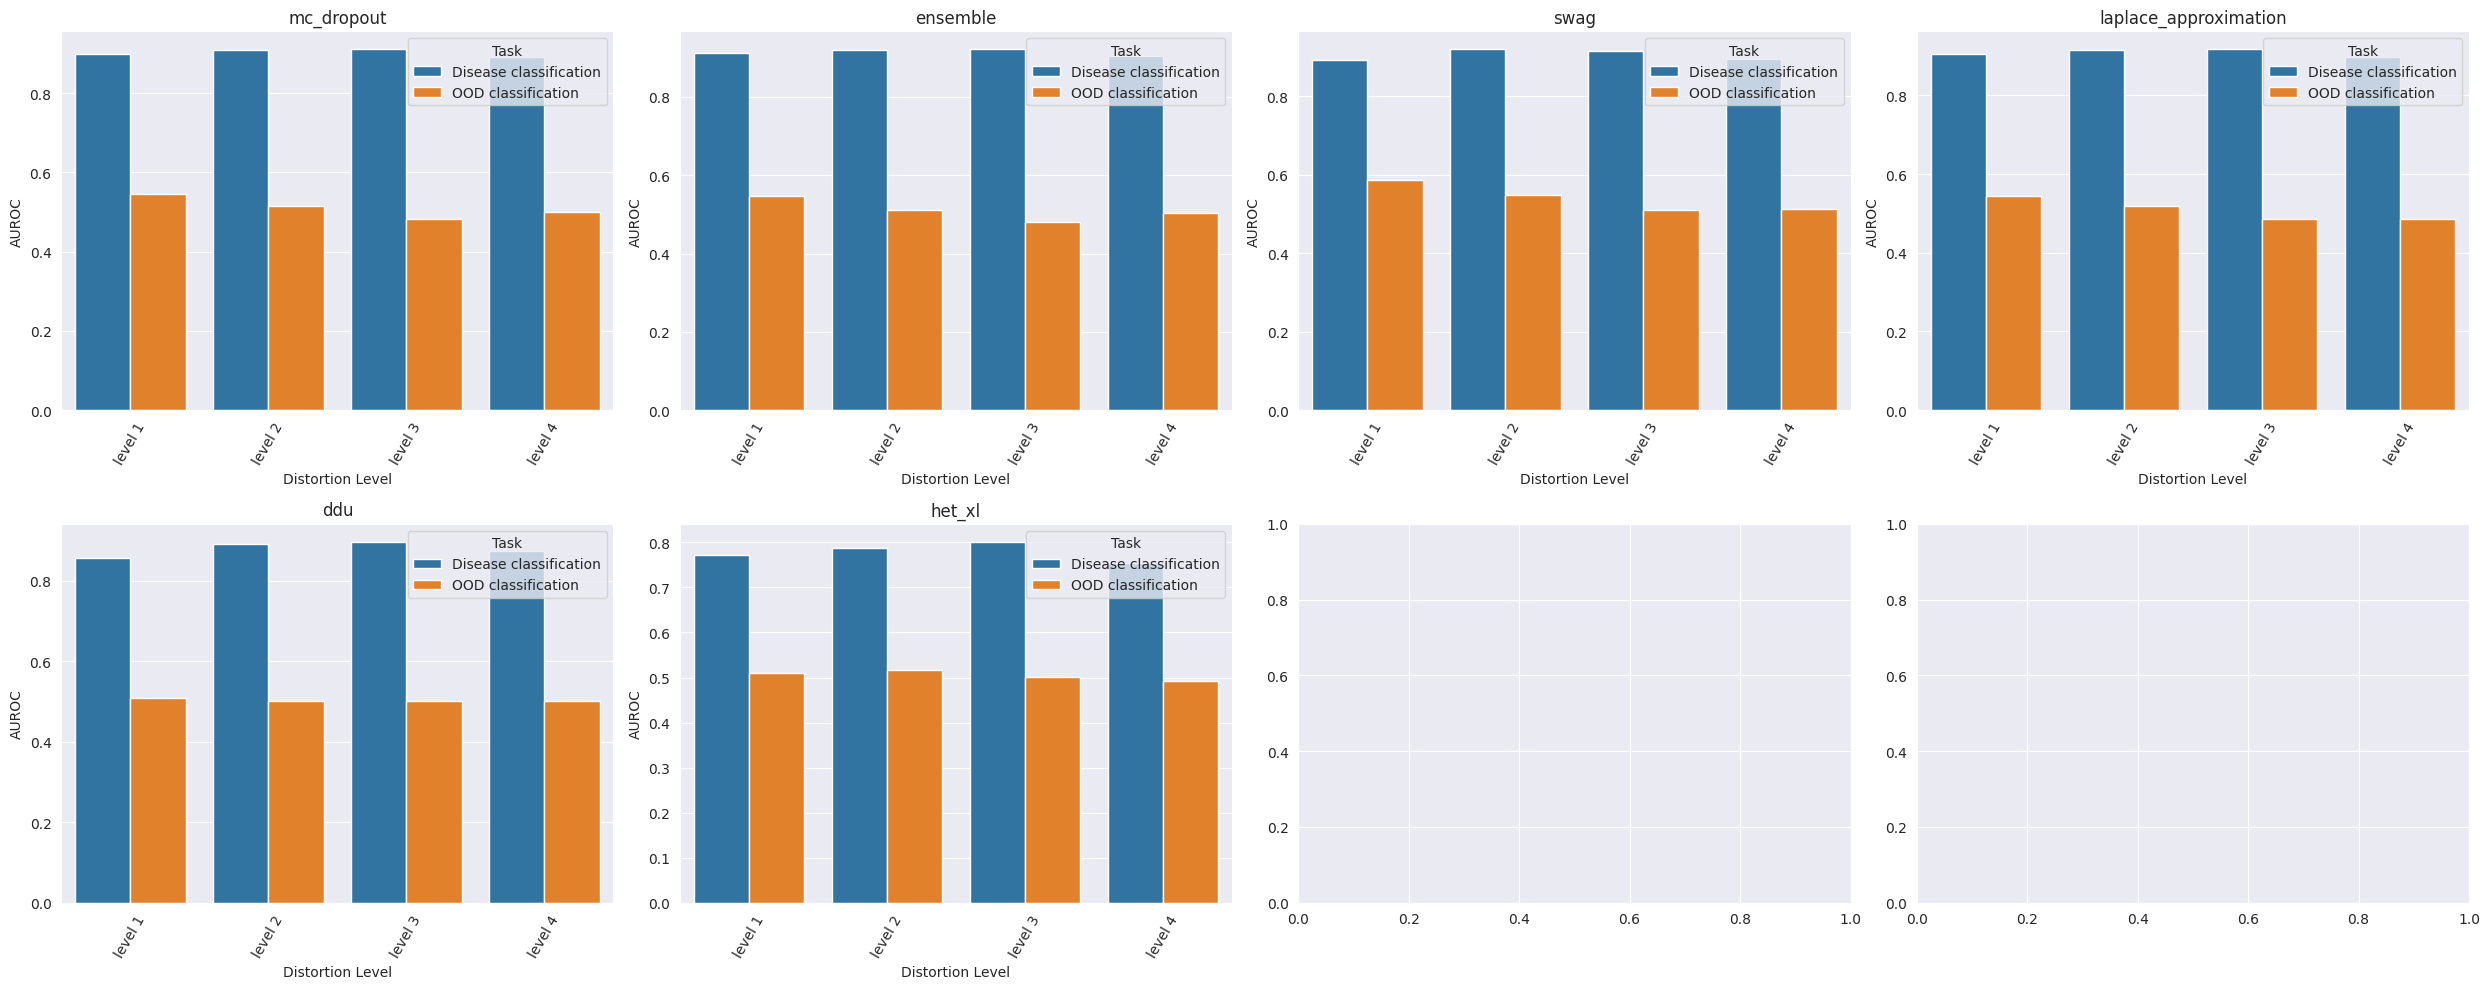

level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.922077  Disease classification
2          level 2  0.899417  Disease classification
4          level 3  0.865293  Disease classification
level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.928634  Disease classification
2          level 2  0.917608  Disease classification
4          level 3  0.884583  Disease classification
level 1 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 2 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 3 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.924660  Disease classification
2          level 2  0.907485  Disease classification
4          level 3  0.872831  Disease classification
level 1 [0 1 2 3 4 5]


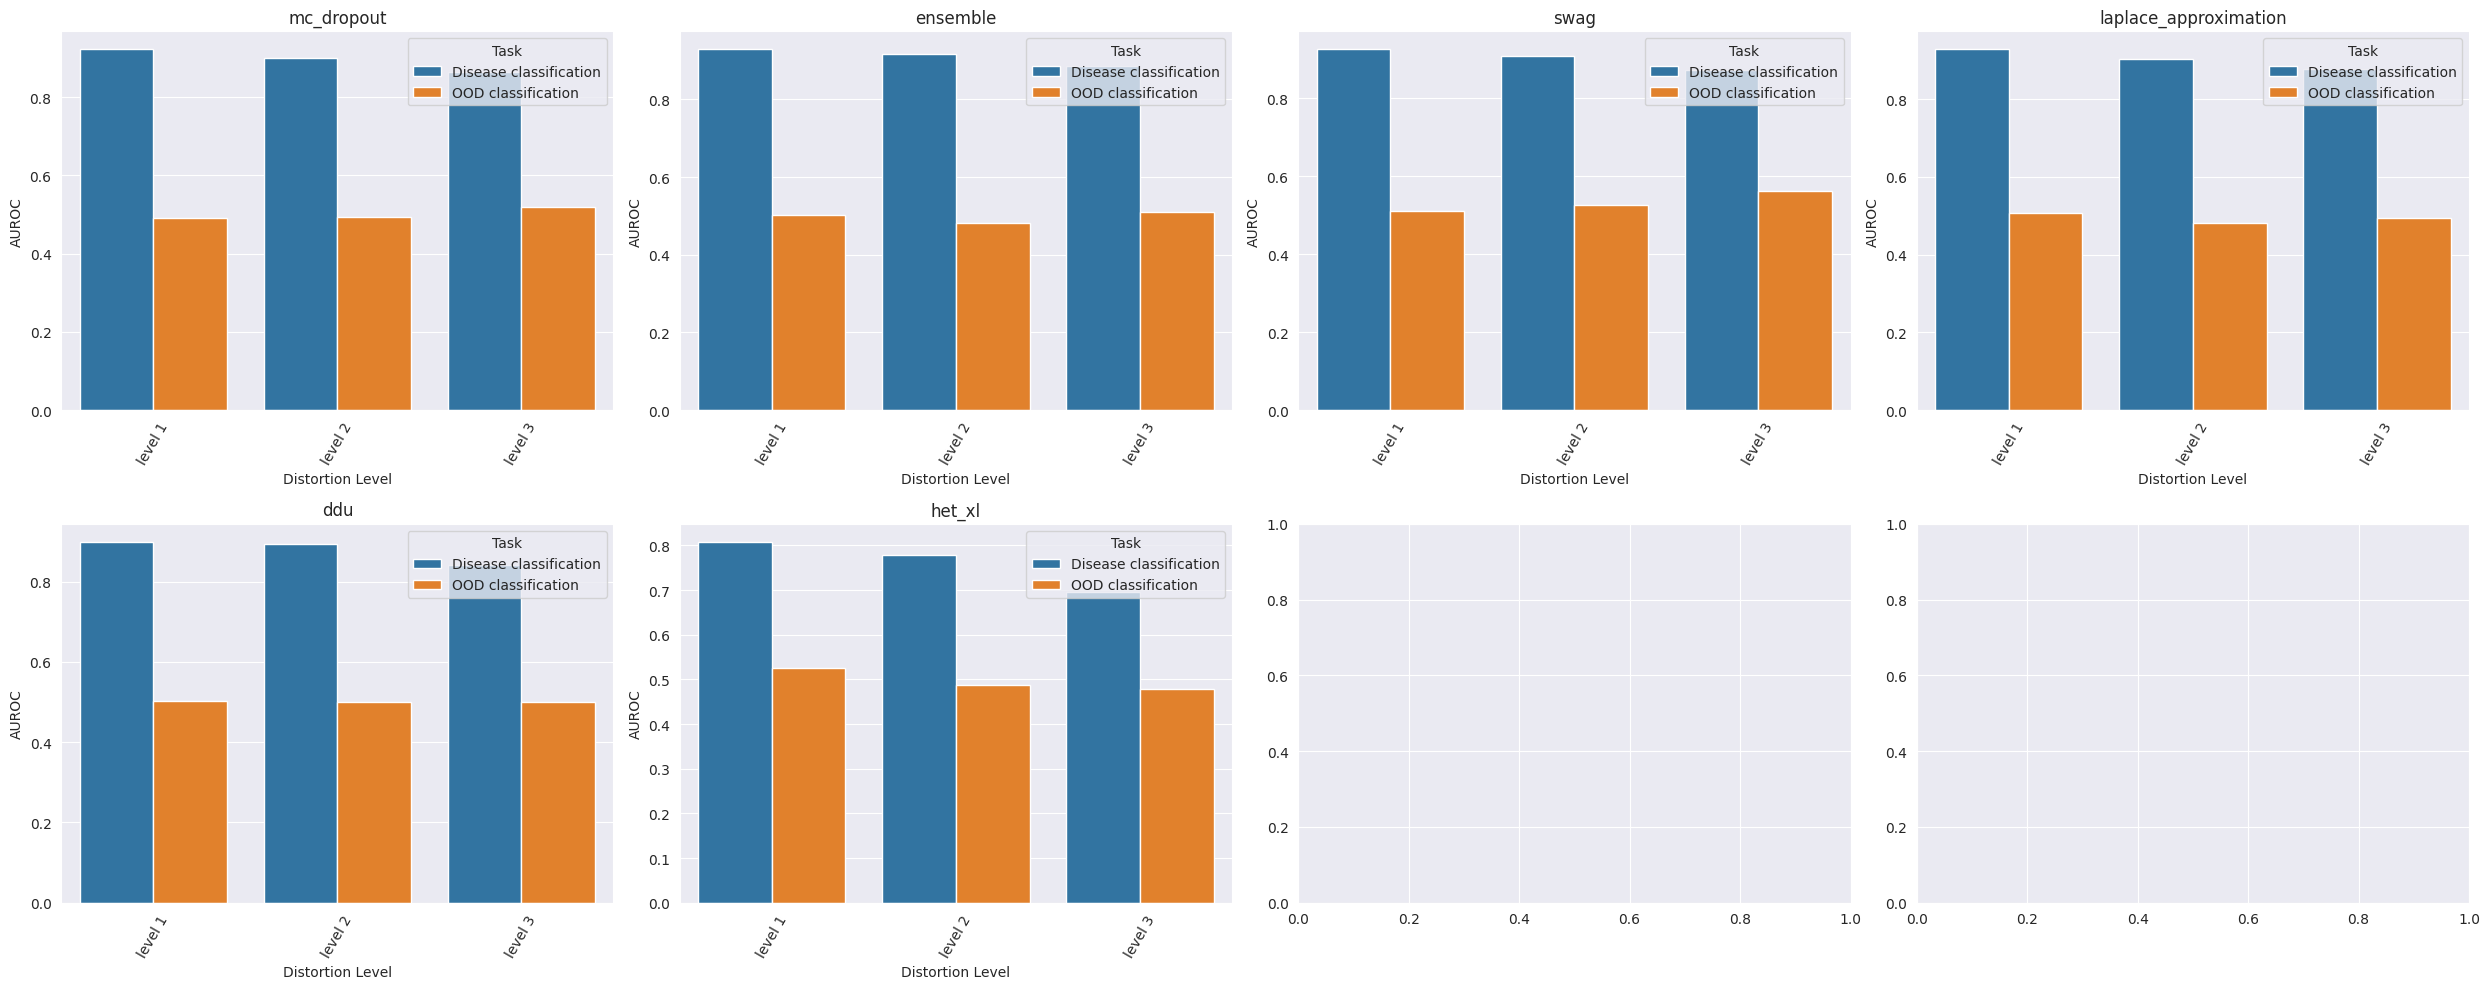

level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.896379  Disease classification
2          level 2  0.910614  Disease classification
4          level 3  0.891487  Disease classification
6          level 4  0.908007  Disease classification
level 1 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 2 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 3 [0 1 2 3 4 5]
[0 1 2 3 4 5]
level 4 [0 1 2 3 4 5]
[0 1 2 3 4 5]
  Distortion Level     AUROC                    Task
0          level 1  0.908290  Disease classification
2          level 2  0.923383  Disease classification
4          level 3  0.910510  Disease classification
6          level 4  0.923906  Disease classification
level 1 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 2 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 3 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
level 4 [0. 1. 2. 3. 4. 5.]
[0 1 2 3 4 5]
  Distortion L

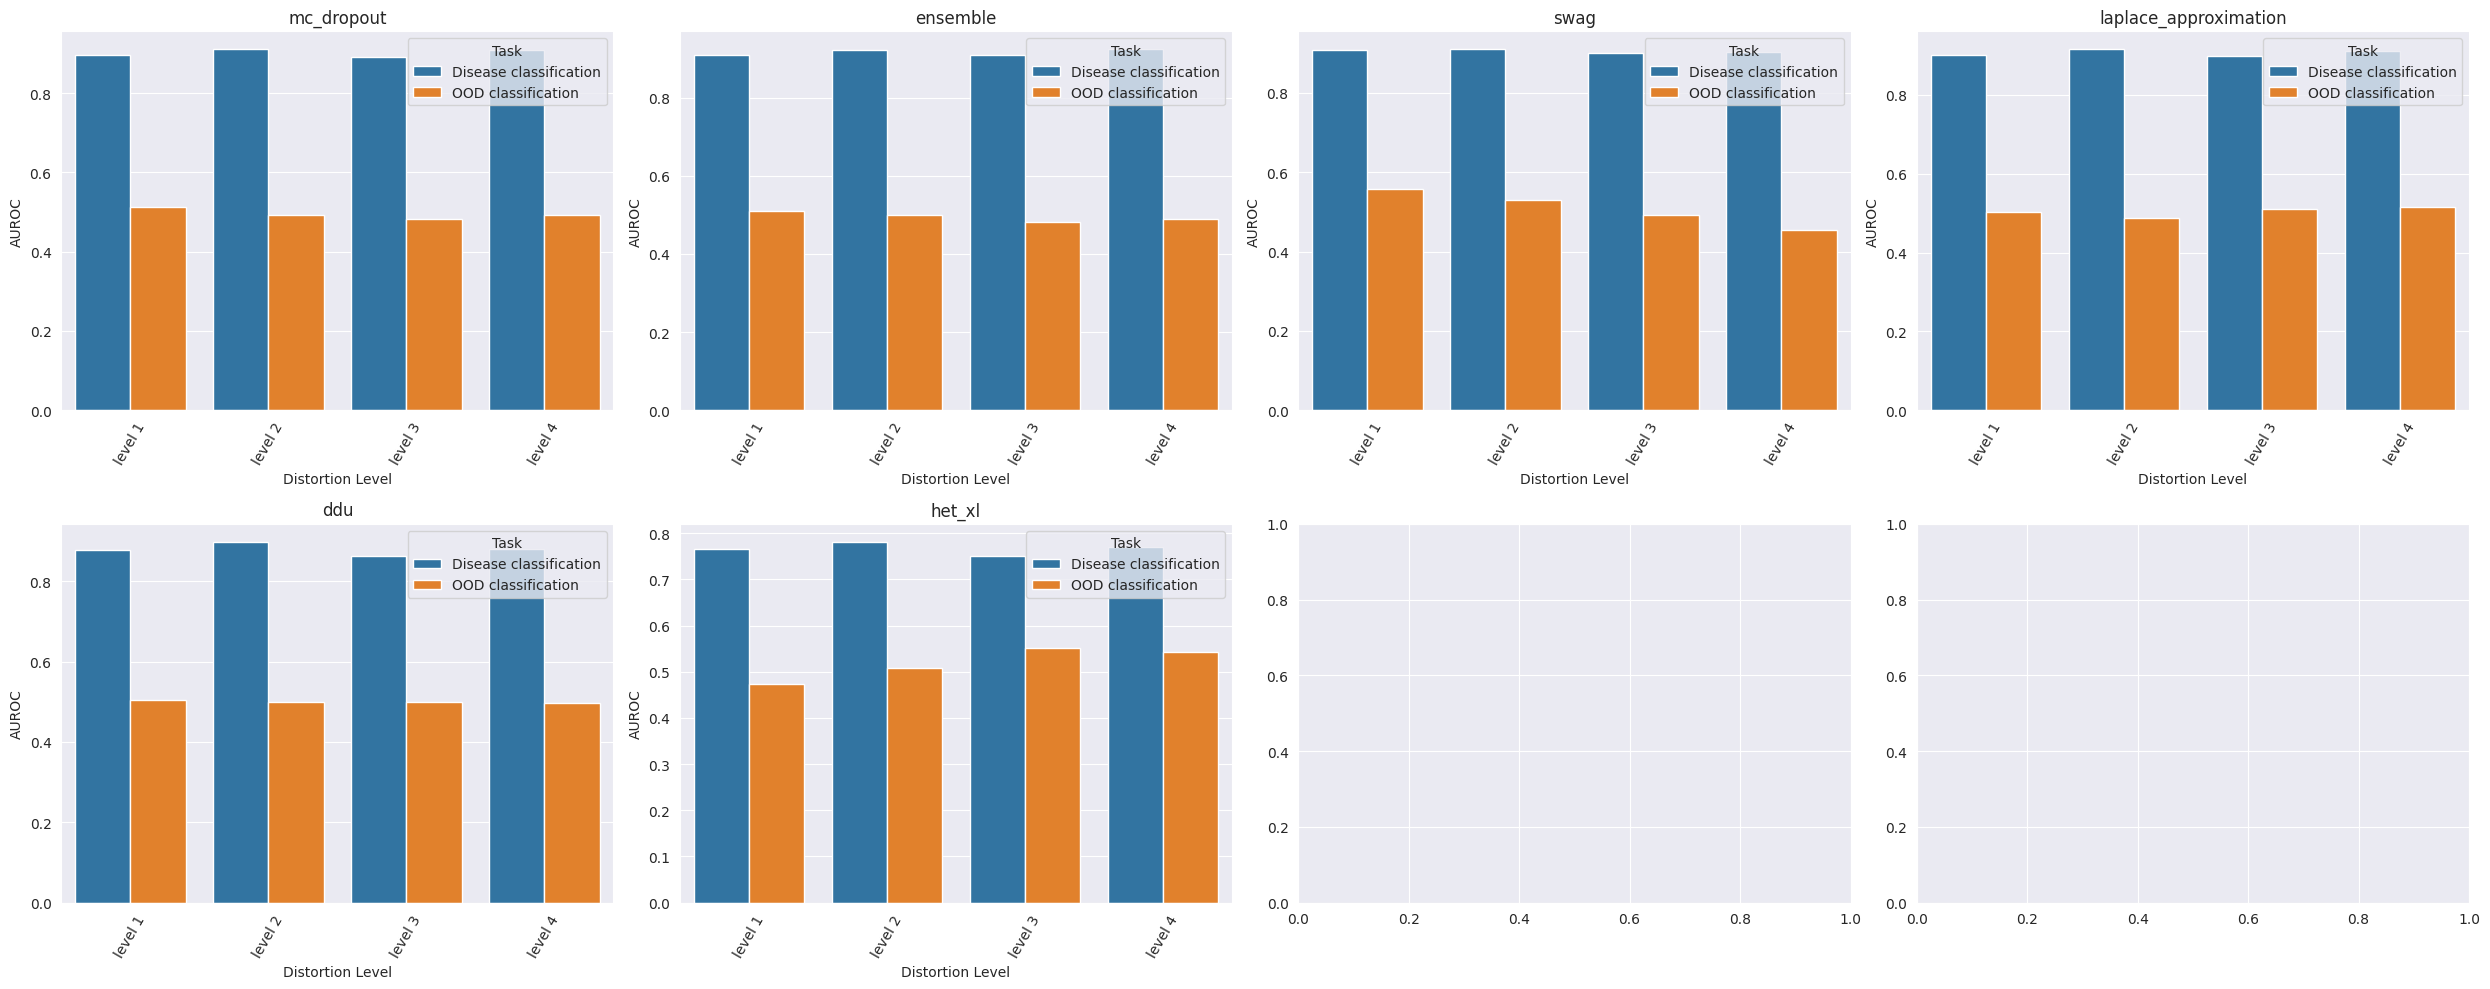

In [22]:
for dist_type in list(test_dl.keys()):
    uncertainty_type = 'epistemic_uncertainty'
    fig, ax = plt.subplots(2,4, figsize=(25,10))
    for i, m in enumerate(methods[uncertainty_type]):
        id_uncertainty = dict()
        for j in range(5):
            res = pickle.load(open(os.path.join(root, m, 'result', f'id_uncertainty_{j}.pkl'), 'rb'))
            for key, value in res.items():
                id_uncertainty[key] = torch.cat([id_uncertainty[key], value]) if key in id_uncertainty else value
        rows = []
        for distortion in test_dl[dist_type].keys():

            data = dict()
            for j in range(5):
                res = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{j}.pkl'), 'rb'))
                for key, value in res.items():
                    data[key] = torch.cat([data[key], value]) if key in data else value
            predictions = data["predictions"].numpy()
            gt = data["ground_truth"].numpy()
            print(distortion, np.unique(gt))


            present_classes = np.unique(gt).astype(int)
            print(present_classes)
            probs = predictions[:, present_classes]
            probs = probs / probs.sum(axis=1, keepdims=True)

            auroc = roc_auc_score(
                gt,
                probs,
                multi_class='ovr',
                labels=present_classes
            )
            # auroc = roc_auc_score(gt, predictions, multi_class='ovr', labels=[0,1,2,3,4,5])
            rows.append({
                    'Distortion Level': distortion,
                    'AUROC': auroc,
                    'Task': 'Disease classification'
                })

            uncertainty = data[uncertainty_type].numpy()
            true_labels = np.concatenate(
                [np.zeros_like(id_uncertainty[uncertainty_type]), np.ones_like(uncertainty)])
            uncertainty_scores = np.concatenate(
                [id_uncertainty[uncertainty_type], uncertainty])  # higher = more OOD-like
            auroc = roc_auc_score(true_labels, uncertainty_scores)
            rows.append({
                'Distortion Level': distortion,
                'AUROC': auroc,
                'Task': 'OOD classification'
            })

        res = pd.DataFrame(rows)
        print(res[res['Task']=='Disease classification'])
        sns.barplot(x="Distortion Level", y="AUROC", hue='Task', data=res, ax=ax[i//4, i%4])
        ax[i//4, i%4].tick_params(axis='x', rotation=60)
        ax[i//4, i%4].set_title(m)
    plt.tight_layout()
    plt.savefig(os.path.join(root, 'common', 'plots', f'auroc_{dist_type}.pdf'))
    plt.show()

/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is pres

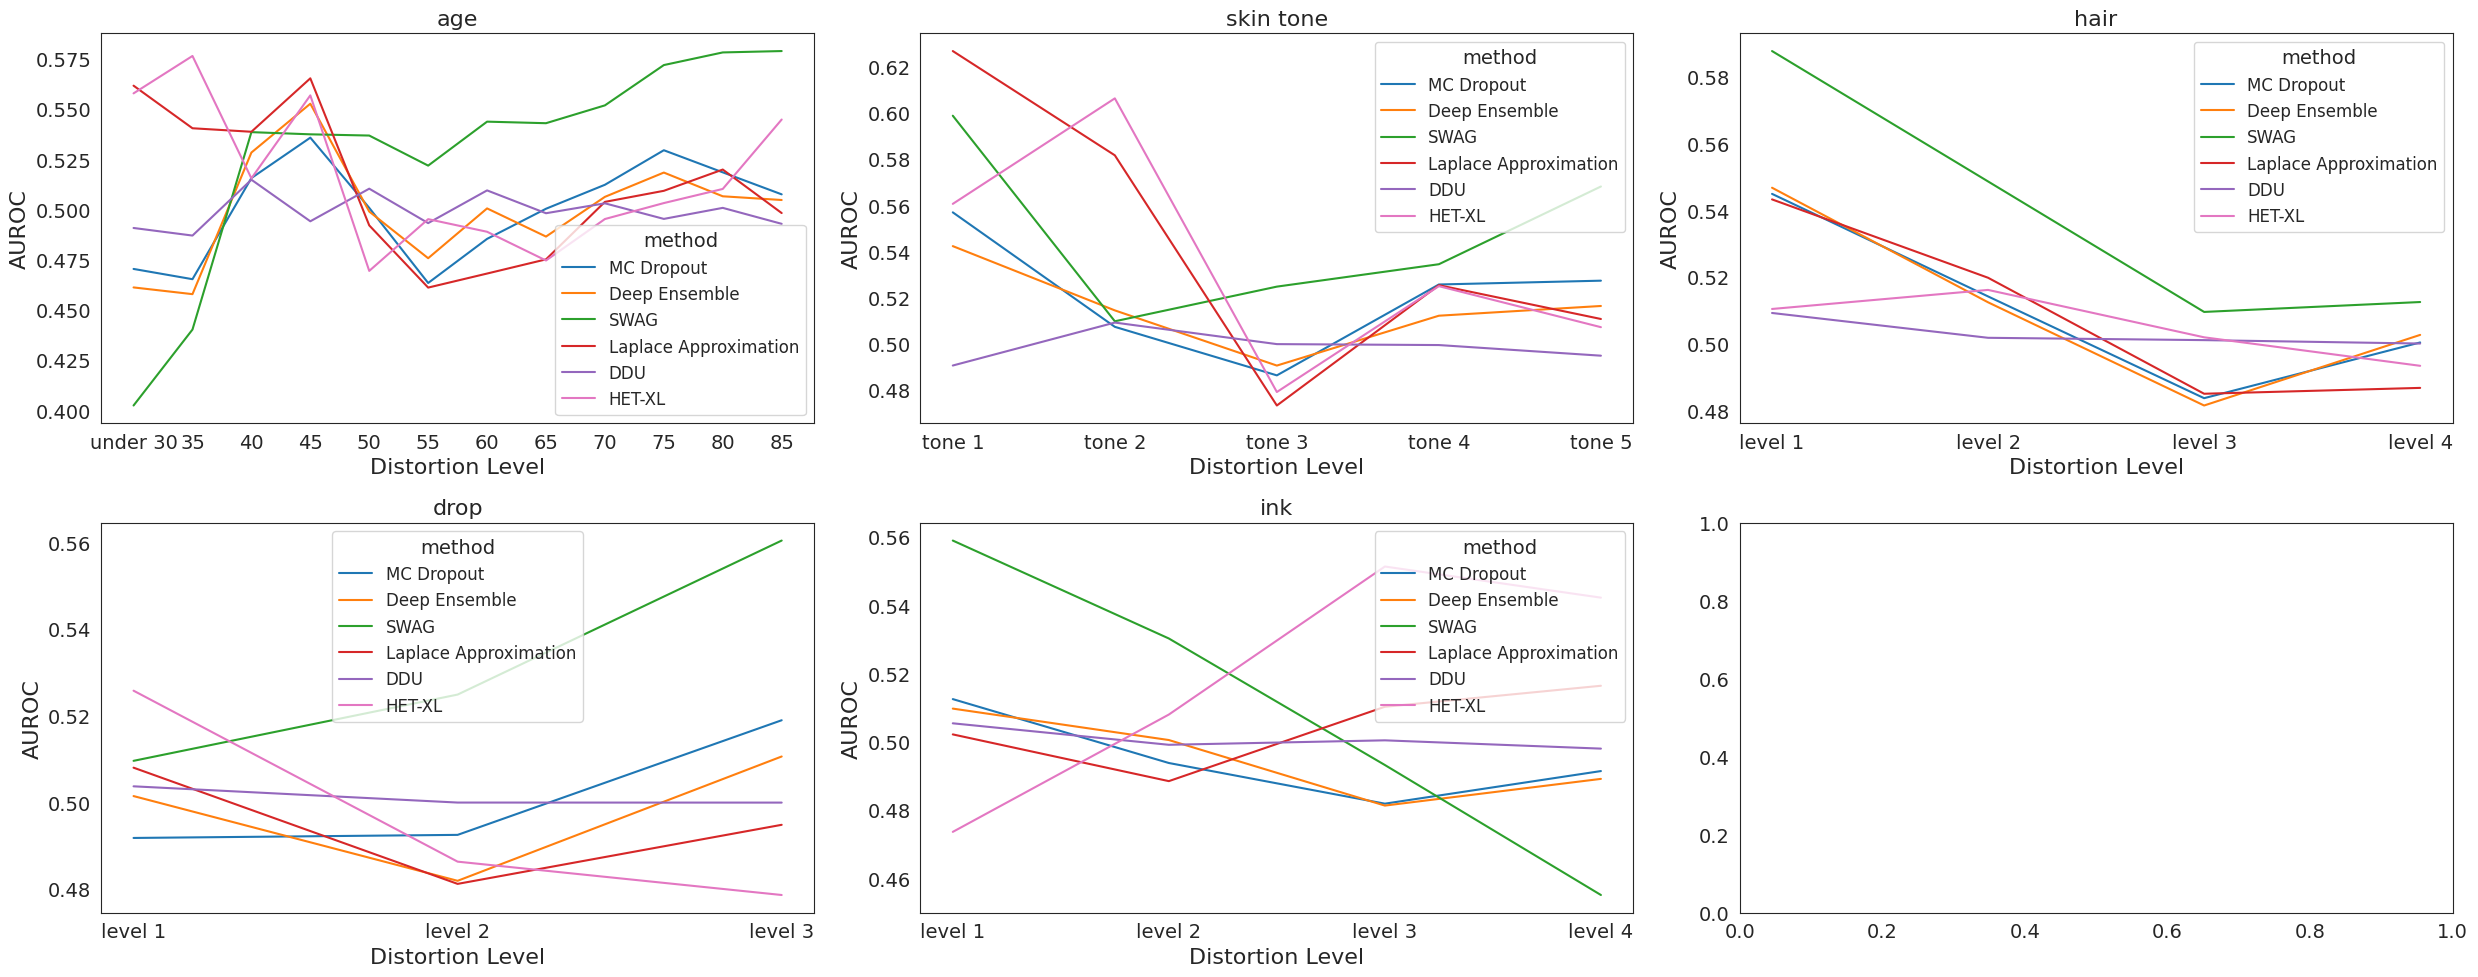

/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is pres

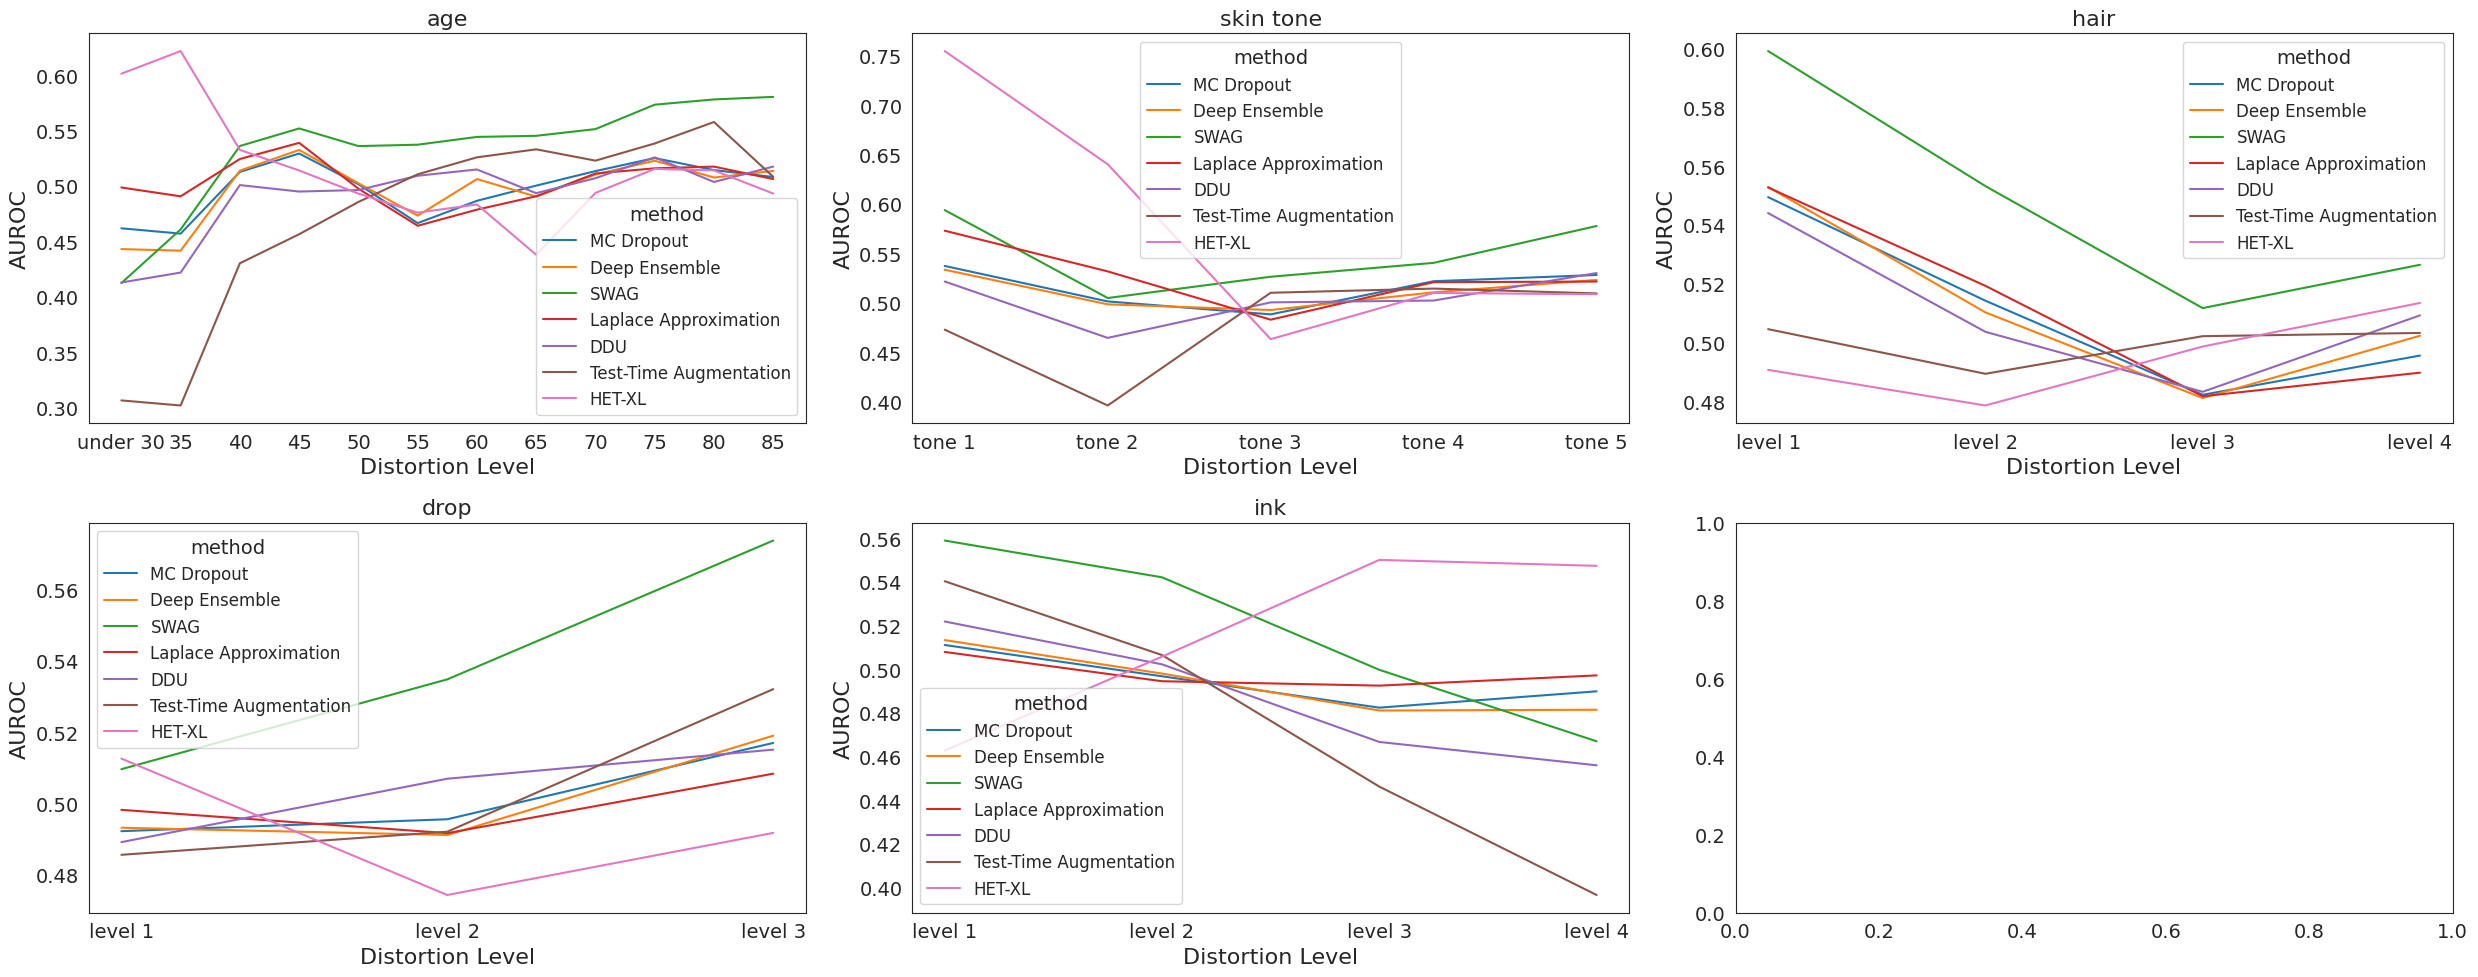

/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/msafa/PhD/benchmark/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is pres

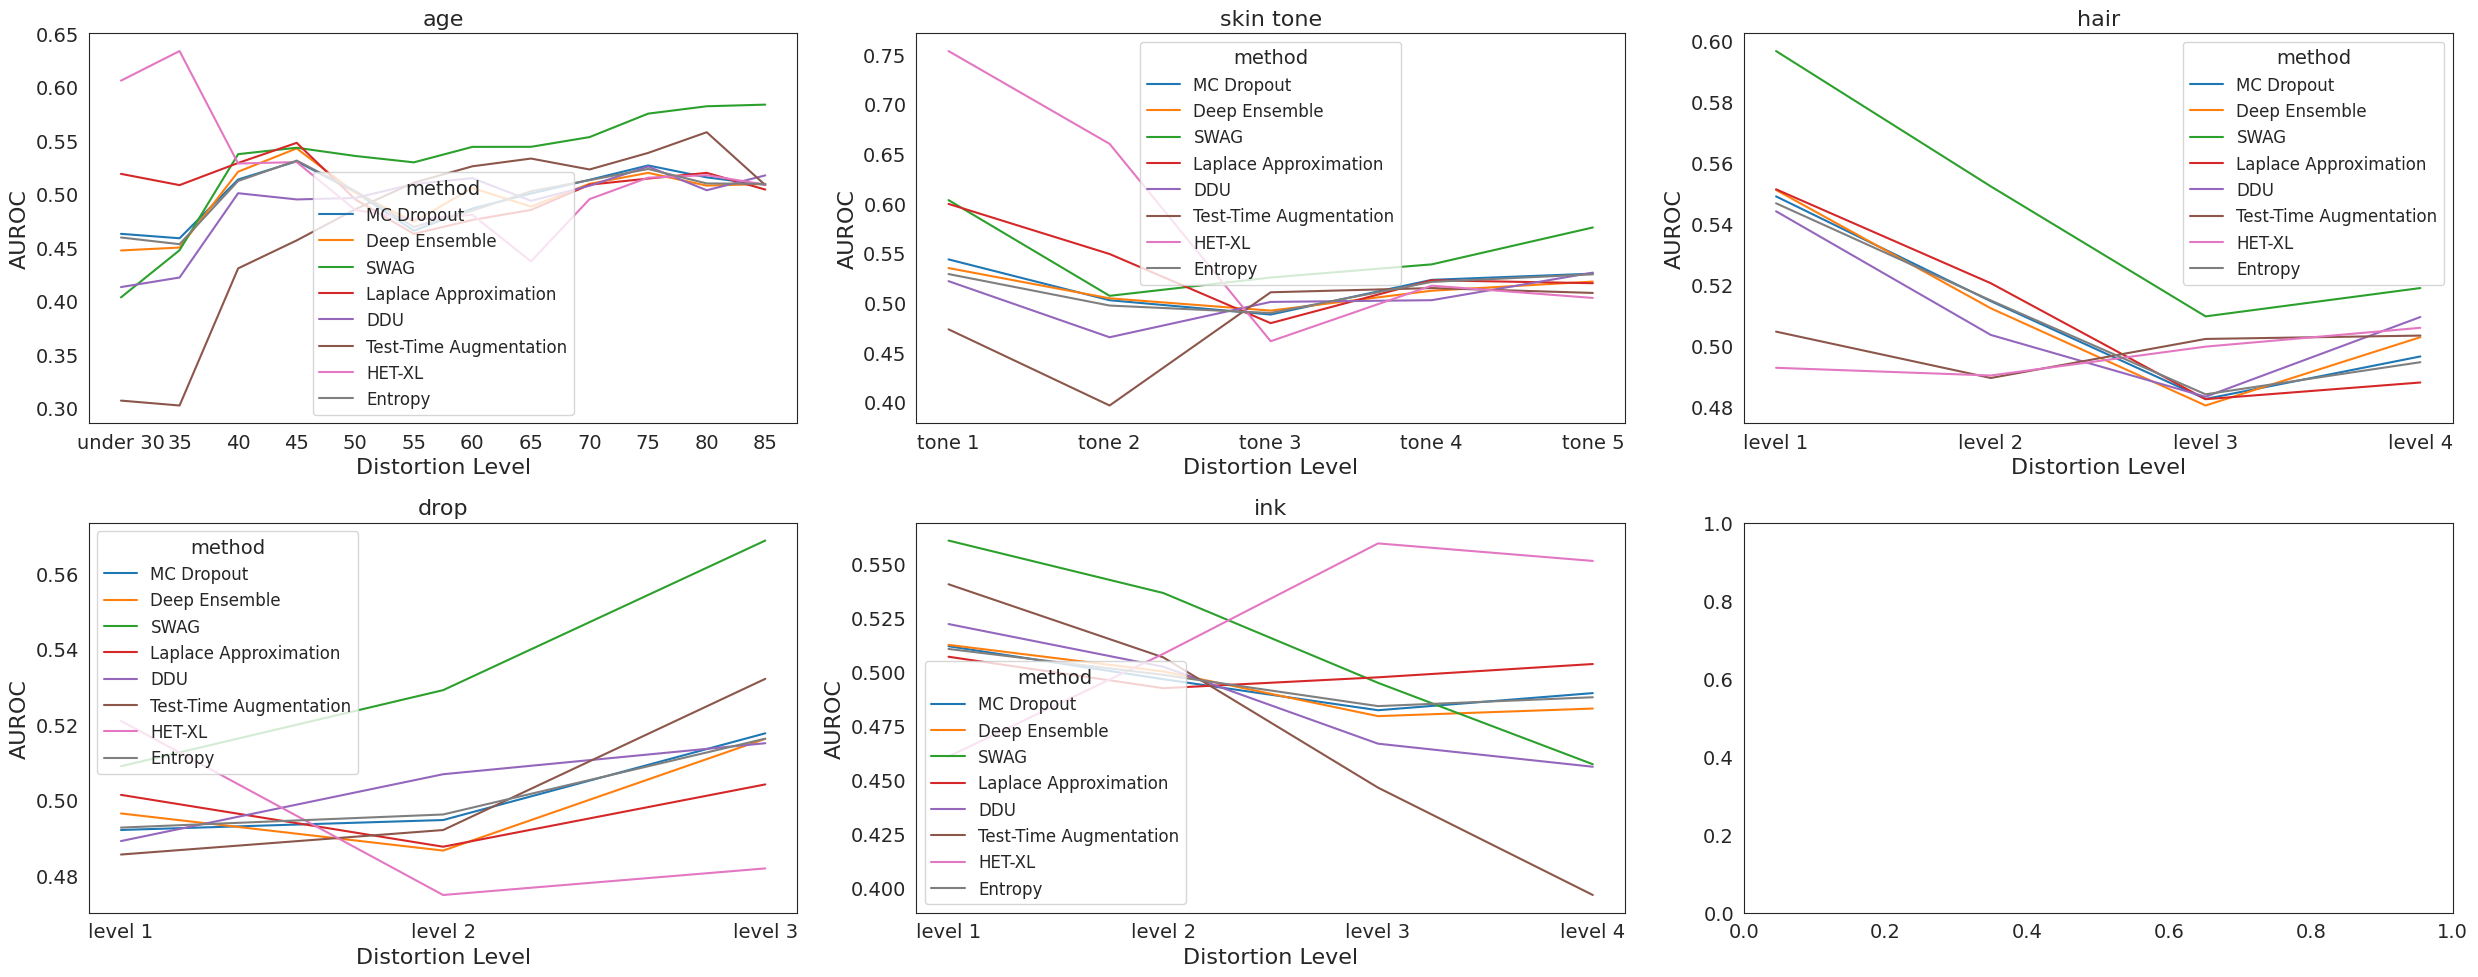

In [7]:
sns.set_style('white')
plt.rcParams.update({"font.size": 14, "xtick.labelsize": 14, "ytick.labelsize": 14, "axes.labelsize": 16, "axes.titlesize": 16, "legend.fontsize": 12})
for uncertainty_type in ['epistemic_uncertainty', 'aleatoric_uncertainty', 'total_uncertainty']:
    n_cols = int(np.ceil(len(test_dl.keys())/2))
    fig, ax = plt.subplots(2,n_cols, figsize=(25,10))
    for i,dist_type in enumerate(list(test_dl.keys())):
        rows = []
        for j, m in enumerate(methods[uncertainty_type]):
            id_uncertainty = dict()
            for j in range(5):
                res = pickle.load(open(os.path.join(root, m, 'result', f'id_uncertainty_{j}.pkl'), 'rb'))
                for key, value in res.items():
                    id_uncertainty[key] = torch.cat([id_uncertainty[key], value]) if key in id_uncertainty else value
            for distortion in test_dl[dist_type].keys():
                data = dict()
                for j in range(5):
                    res = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{j}.pkl'), 'rb'))
                    for key, value in res.items():
                        data[key] = torch.cat([data[key], value]) if key in data else value
                predictions = data["predictions"].numpy()
                if len(predictions.shape) > 2:
                    predictions = np.mean(predictions, axis=0)
                gt = data["ground_truth"].numpy()

                auroc = roc_auc_score(gt, predictions, multi_class='ovr', labels=list(range(6)) )
                rows.append({
                        'Distortion Level': distortion,
                        'AUROC': auroc,
                        'Task': 'Digit classification',
                        'method': legened_map[m]
                    })

                uncertainty = data[uncertainty_type].numpy()
                true_labels = np.concatenate(
                    [np.zeros_like(id_uncertainty[uncertainty_type]), np.ones_like(uncertainty)])
                uncertainty_scores = np.concatenate(
                    [id_uncertainty[uncertainty_type], uncertainty])  # higher = more OOD-like
                auroc = roc_auc_score(true_labels, uncertainty_scores)
                rows.append({
                    'Distortion Level': distortion,
                    'AUROC': auroc,
                    'Task': 'OOD classification',
                    'method': legened_map[m]
                })

        res = pd.DataFrame(rows)
        sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res[res['Task']=='OOD classification'], ax=ax[i//n_cols, i%n_cols], palette=palette_dict)
        # ax[i//n_cols, i%n_cols].tick_params(axis='x', rotation=60)
        ax[i//n_cols, i%n_cols].set_title(dist_type)

    plt.tight_layout()
    plt.savefig(os.path.join(root, 'common', 'plots', f'auroc_line_{uncertainty_type}.pdf'))
    plt.show()

mc_dropout tensor(0.7559)
ensemble tensor(0.7612)
swag tensor(0.7549)
laplace_approximation tensor(0.7570)
ddu tensor(0.7545)
TTA tensor(0.4097)
het_xl tensor(0.5818)
entropy tensor(0.7565)


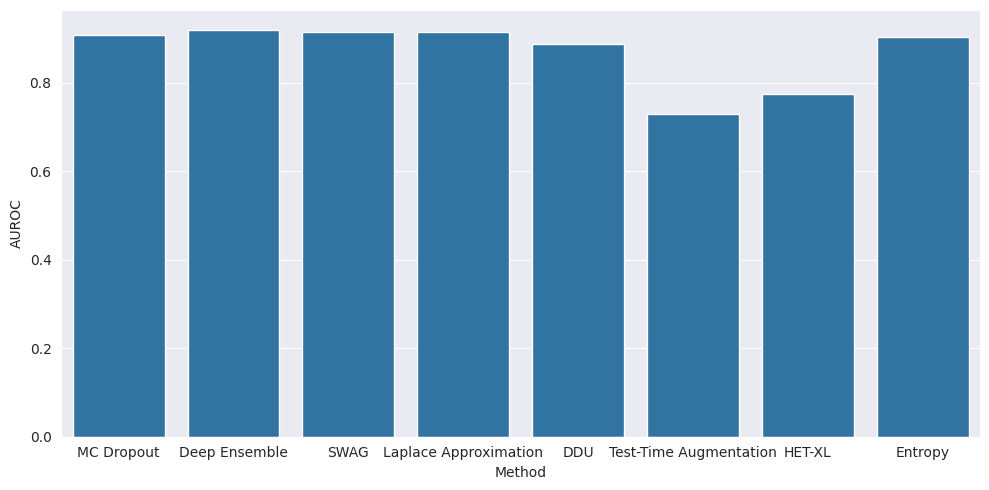

In [7]:
uncertainty_type = 'total_uncertainty'

fig, ax = plt.subplots(figsize=(10,5))
rows = []
for j, m in enumerate(methods[uncertainty_type]):
    id_uncertainty = dict()
    for j in range(5):
        res = pickle.load(open(os.path.join(root, m, 'result', f'id_uncertainty_{j}.pkl'), 'rb'))
        for key, value in res.items():
            id_uncertainty[key] = torch.cat([id_uncertainty[key], value]) if key in id_uncertainty else value
    print(m, (id_uncertainty['ground_truth']==id_uncertainty['predicted_labels']).sum() / len(id_uncertainty['ground_truth']))

    auroc = roc_auc_score(id_uncertainty['ground_truth'].numpy(), id_uncertainty['predictions'].numpy(), multi_class='ovr', labels=list(range(6)) )
    rows.append({
            'AUROC': auroc,
            'Task': 'Digit classification',
            'Method': legened_map[m]
        })

res = pd.DataFrame(rows)
sns.barplot(x="Method", y="AUROC", data=res)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'main_task_auroc.pdf'))
plt.show()

### misclassification

/tmp/ipykernel_9630/3599573178.py:29: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res, ax=ax[i//n_cols, i%n_cols], palette=sns.color_palette('tab10'))
/tmp/ipykernel_9630/3599573178.py:29: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res, ax=ax[i//n_cols, i%n_cols], palette=sns.color_palette('tab10'))
/tmp/ipykernel_9630/3599573178.py:29: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res, ax=ax[i//n_cols, i%n_cols], palette=sns.color_palette('tab10'))
/tmp/ipykernel_9630/3599573178.py:29: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.lineplot(x="Distortion Level", y="AUROC", hue='method'

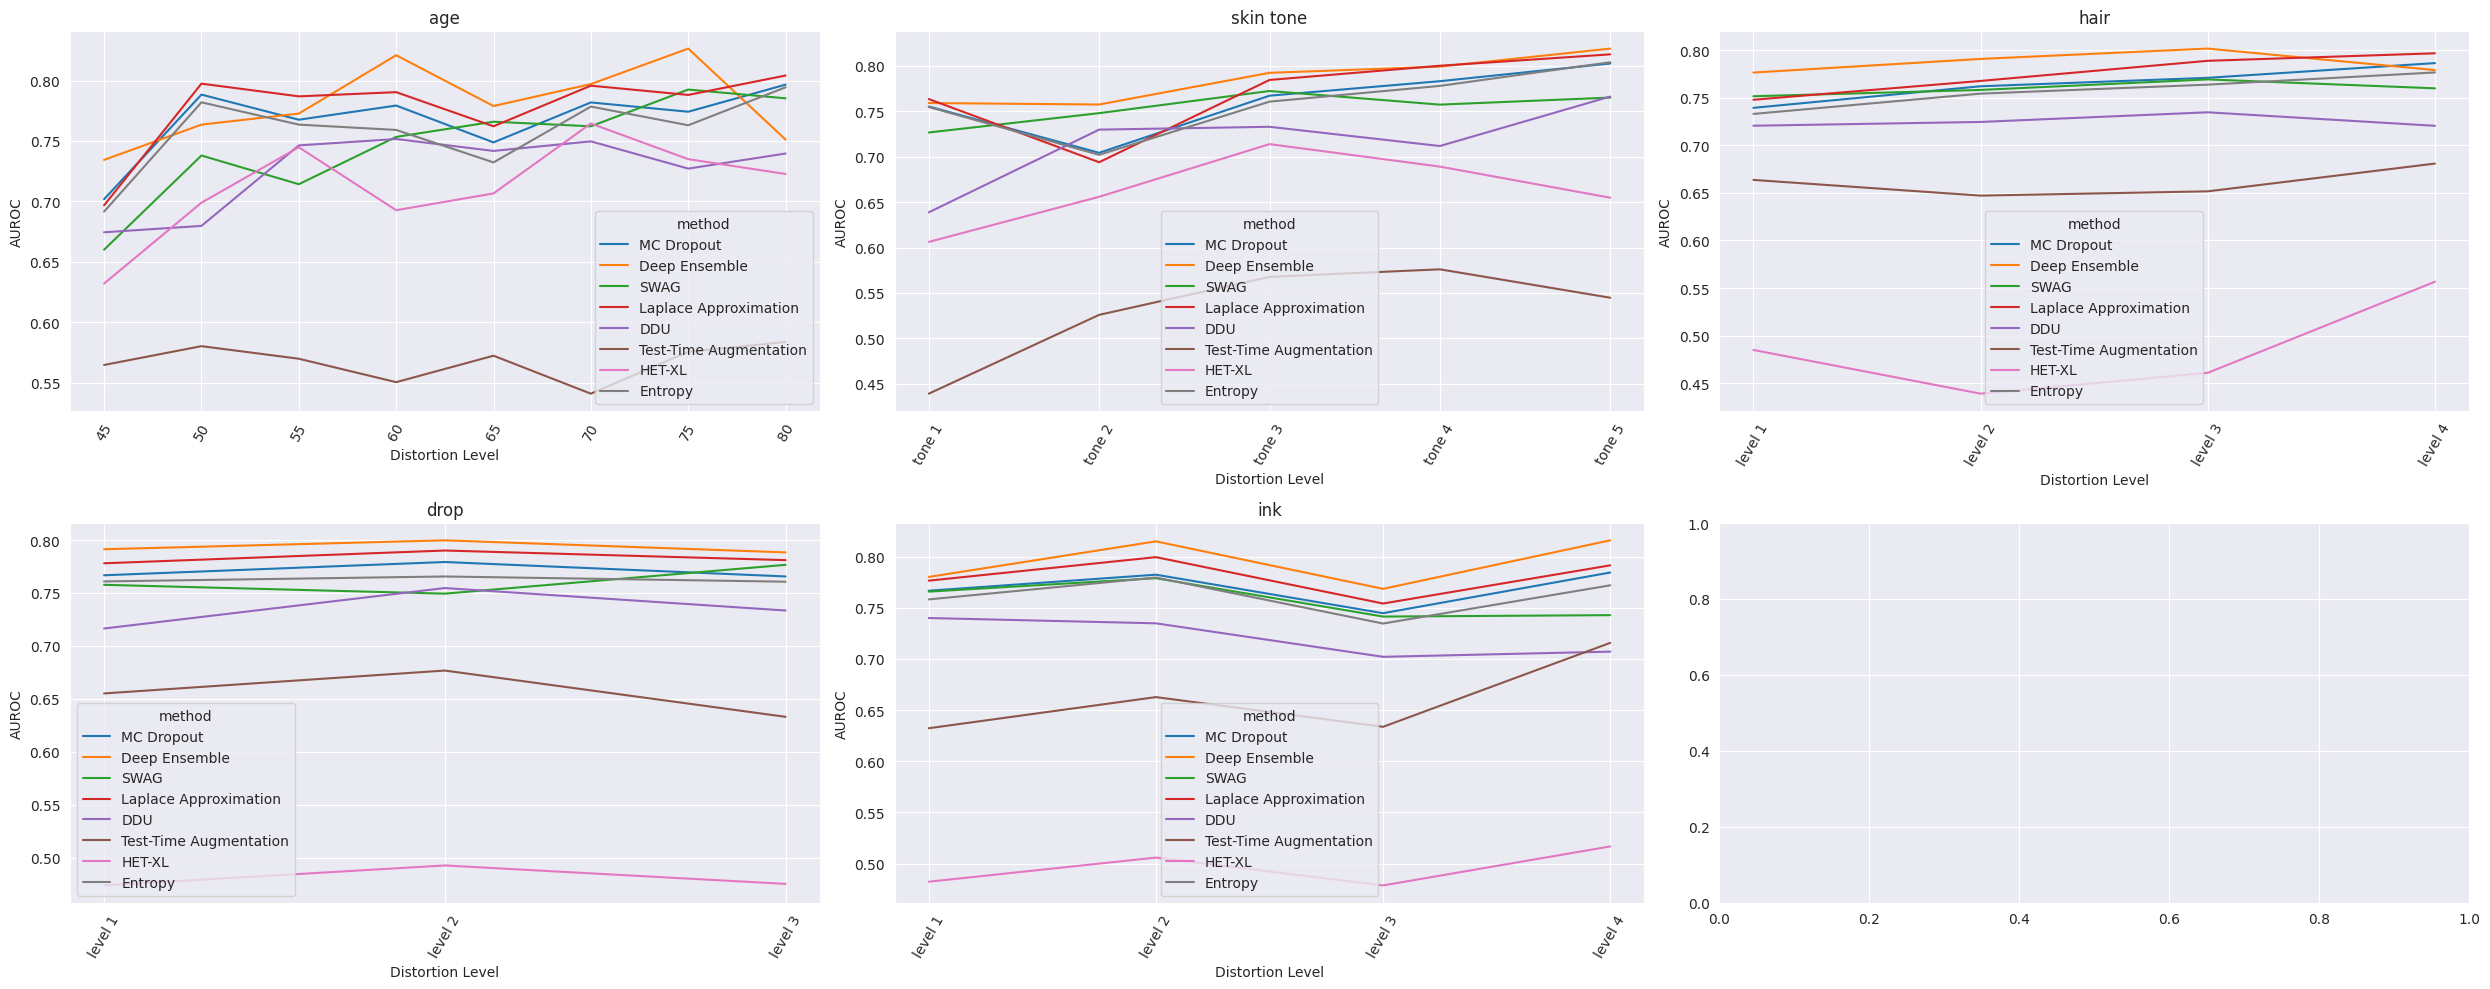

In [9]:
uncertainty_type = 'total_uncertainty'
n_cols = int(np.ceil(len(test_dl.keys())/2))
fig, ax = plt.subplots(2,n_cols, figsize=(25,10))
for i,dist_type in enumerate(list(test_dl.keys())):
    rows = []
    for j, m in enumerate(methods[uncertainty_type]):
        id_uncertainty = dict()
        for j in range(5):
            res = pickle.load(open(os.path.join(root, m, 'result', f'id_uncertainty_{j}.pkl'), 'rb'))
            for key, value in res.items():
                id_uncertainty[key] = torch.cat([id_uncertainty[key], value]) if key in id_uncertainty else value
        for distortion in test_dl[dist_type].keys():
            data = dict()
            for j in range(5):
                res = pickle.load(open(os.path.join(root, m, 'result', f'testset_uncertainty_{dist_type}_{distortion}_{j}.pkl'), 'rb'))
                for key, value in res.items():
                    data[key] = torch.cat([data[key], value]) if key in data else value

            uncertainty = data[uncertainty_type].numpy()
            true_labels = data['predicted_labels']!=data['ground_truth']
            auroc = roc_auc_score(true_labels, uncertainty)
            rows.append({
                'Distortion Level': distortion,
                'AUROC': auroc,
                'method': legened_map[m]
            })

    res = pd.DataFrame(rows)
    sns.lineplot(x="Distortion Level", y="AUROC", hue='method', data=res, ax=ax[i//n_cols, i%n_cols], palette=sns.color_palette('tab10'))
    ax[i//n_cols, i%n_cols].tick_params(axis='x', rotation=60)
    ax[i//n_cols, i%n_cols].set_title(dist_type)

plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', f'misclassification_line.pdf'))
plt.show()

In [9]:
test_dl.keys()

dict_keys(['age', 'skin tone', 'hair', 'drop', 'ink'])

In [8]:
for file in glob('/home/msafa/PhD/benchmark/experiments/isic_result/TTA/result/*.pkl'):
    data = pickle.load(open(file, 'rb'))
    data['total_uncertainty'] = data['aleatoric_uncertainty']
    with open(file, 'wb') as f:
        pickle.dump(data, f)

age under 30 52
age under 30 60
age under 30 35
age under 30 47
age under 30 55
age 35 23
age 35 25
age 35 24
age 35 21
age 35 30
age 40 46
age 40 42
age 40 38
age 40 45
age 40 39
age 45 59
age 45 56
age 45 42
age 45 48
age 45 56
age 50 88
age 50 69
age 50 80
age 50 89
age 50 80
age 55 89
age 55 91
age 55 100
age 55 85
age 55 105
age 60 116
age 60 124
age 60 110
age 60 126
age 60 100
age 65 143
age 65 158
age 65 134
age 65 130
age 65 148
age 70 148
age 70 134
age 70 174
age 70 141
age 70 130
age 75 124
age 75 95
age 75 128
age 75 113
age 75 130
age 80 63
age 80 70
age 80 70
age 80 84
age 80 76
age 85 57
age 85 81
age 85 66
age 85 74
age 85 55
mc_dropout 5021
age under 30 52
age under 30 60
age under 30 35
age under 30 47
age under 30 55
age 35 23
age 35 25
age 35 24
age 35 21
age 35 30
age 40 46
age 40 42
age 40 38
age 40 45
age 40 39
age 45 59
age 45 56
age 45 42
age 45 48
age 45 56
age 50 88
age 50 69
age 50 80
age 50 89
age 50 80
age 55 89
age 55 91
age 55 100
age 55 85
age 55 105
a

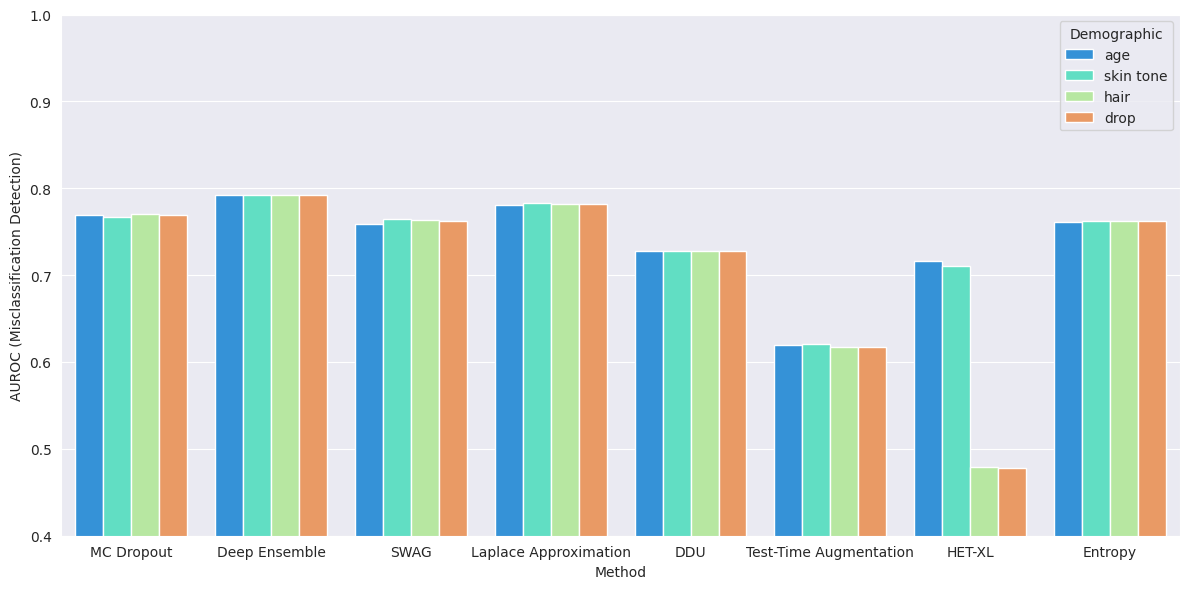

In [9]:
rows = []
uncertainty_type = 'total_uncertainty'
for dist_type in ['age', 'skin tone', 'hair', 'drop']:
    for m in methods[uncertainty_type]:

        data = dict()

        for distortion in test_dl[dist_type].keys():
            for seed in range(5):
                res = pickle.load(open(
                    os.path.join(root, m, 'result',
                                 f'testset_uncertainty_{dist_type}_{distortion}_{seed}.pkl'),
                    'rb'))
                print(dist_type, distortion, len(res['ground_truth']))

                for key, value in res.items():
                    data[key] = torch.cat([data[key], value]) if key in data else value

        print(m, len(data['ground_truth']))
        uncertainty = data[uncertainty_type].detach().cpu().numpy()
        true_labels = (data['predicted_labels'] != data['ground_truth']).detach().cpu().numpy()

        auroc = roc_auc_score(true_labels, uncertainty)

        rows.append({
            'Method': legened_map[m],
            'AUROC': auroc,
            'Demographic': dist_type
        })

res = pd.DataFrame(rows)

plt.figure(figsize=(12,6))
# sns.set_palette("Set1")

ax = sns.barplot(x="Method", y="AUROC", hue='Demographic', data=res, palette="rainbow")
ax.set_ylabel("AUROC (Misclassification Detection)")
# ax.tick_params(axis='x', rotation=45)
ax.set_ylim(.40, 1.00)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', 'misclassification.pdf'))
plt.show()

mc_dropout 5038
ensemble 5038
swag 5038
laplace_approximation 5038
ddu 5038
TTA 5038
het_xl 5038
entropy 5038


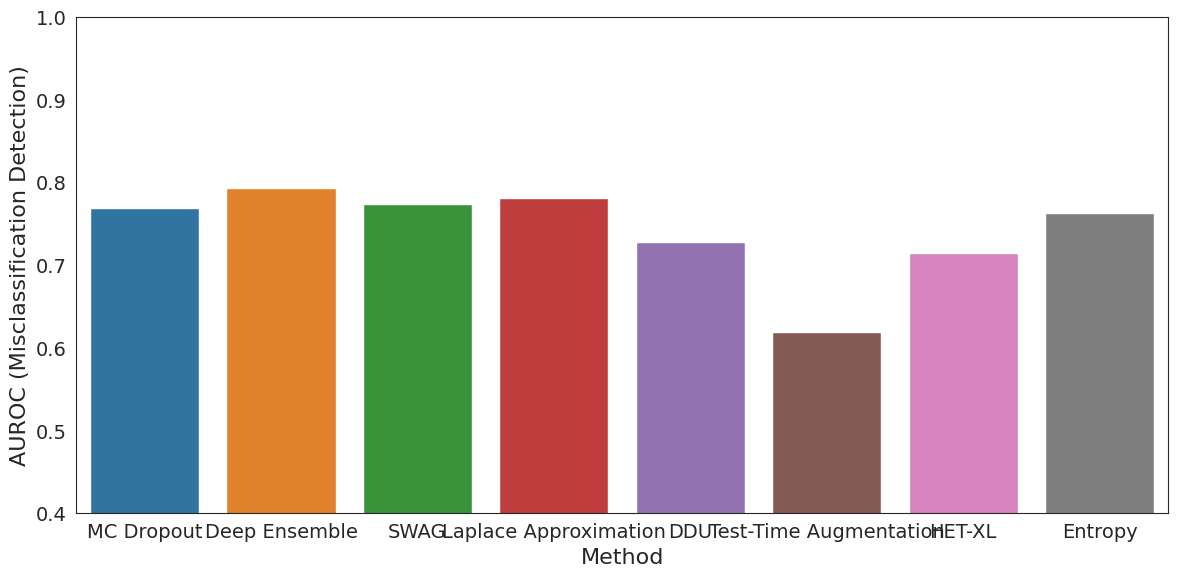

In [6]:
rows = []
uncertainty_type = 'total_uncertainty'
for m in methods[uncertainty_type]:
    data = dict()

    for seed in range(5):
        res = pickle.load(open(
            os.path.join(root, m, 'result',
                         f'id_uncertainty_{seed}.pkl'),
            'rb'))

        for key, value in res.items():
            data[key] = torch.cat([data[key], value]) if key in data else value

    print(m, len(data['ground_truth']))
    uncertainty = data[uncertainty_type].detach().cpu().numpy()
    true_labels = (data['predicted_labels'] != data['ground_truth']).detach().cpu().numpy()

    auroc = roc_auc_score(true_labels, uncertainty)

    rows.append({
        'Method': legened_map[m],
        'AUROC': auroc,
    })

res = pd.DataFrame(rows)

plt.figure(figsize=(12,6))
# sns.set_palette("Set1")

ax = sns.barplot(x="Method", y="AUROC", hue='Method', legend=False, data=res, palette="tab10")
ax.set_ylabel("AUROC (Misclassification Detection)")
# ax.tick_params(axis='x', rotation=45)
ax.set_ylim(.40, 1.00)
plt.tight_layout()
plt.savefig(os.path.join(root, 'common', 'plots', 'misclassification.pdf'))
plt.show()